In [1]:
import numpy as np
import pandas as pd
import fastf1 as ff1

In [2]:
import os

data_dir = './f1_data'
race_file = os.path.join(data_dir, 'f1_strategy_NN_XGB_19_25_encoded.csv')
df_race = pd.read_csv(race_file)

### KMEANS

📊 Loading Circuit Data...
🔍 Ricerca del numero ottimale di cluster...


c:\Users\lucam\anaconda3\envs\myenv_310_f1\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\lucam\anaconda3\envs\myenv_310_f1\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\lucam\anaconda3\envs\myenv_310_f1\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\lucam\anaconda3\envs\myenv_310_f1\lib\site-packages\sklearn\cluster\_kmea

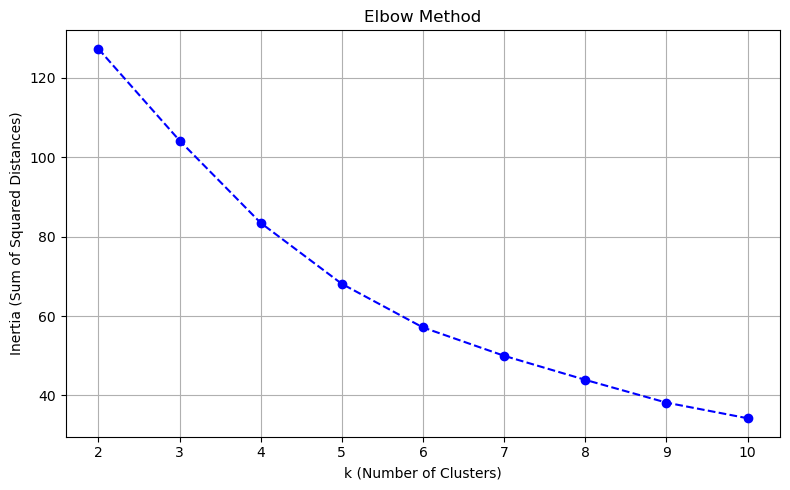

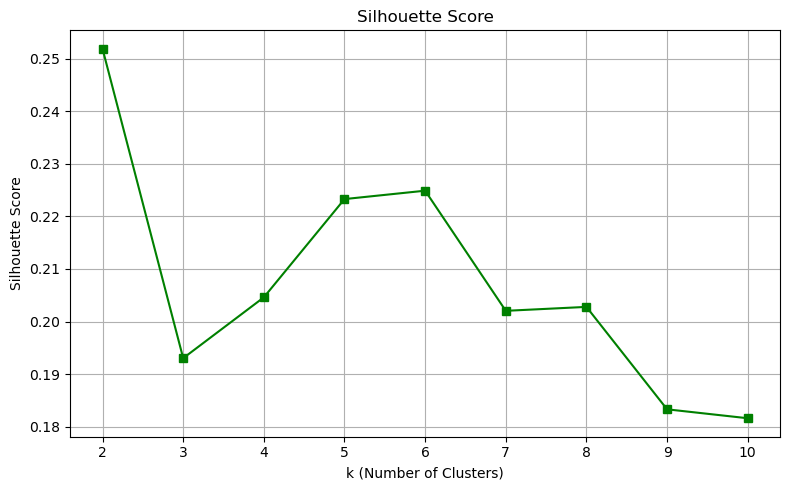

In [1]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# ==========================================
# 1. LOAD AND PREPARE CIRCUIT DATA
# ==========================================
print("📊 Loading Circuit Data...")
circuits_df = pd.read_csv('./f1_data/f1_unique_circuits_complete.csv')

# Select the physical characteristics provided by Pirelli
pirelli_features = [
    'Traction', 'AsphaltGrip', 'AsphaltAbrasion', 
    'TyreStress', 'Braking', 'LateralLoad', 'Downforce'
]

# Extract the features for clustering
X_circuits = circuits_df[pirelli_features]

# Standardize the data (Crucial for K-Means to work properly)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_circuits)

# ==========================================
# 1.5 CONTROLLO DEL NUMERO OTTIMALE DI CLUSTER
# ==========================================
print("🔍 Ricerca del numero ottimale di cluster...")

inertia = []
silhouette_scores = []
K_range = range(2, 11) # Testiamo da 2 a 10 cluster

for k in K_range:
    # Addestriamo il modello temporaneo per testare 'k'
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_temp.fit(X_scaled)
    
    # Salviamo l'inerzia per il Metodo del Gomito
    inertia.append(kmeans_temp.inertia_)
    
    # Salviamo il Silhouette Score
    score = silhouette_score(X_scaled, kmeans_temp.labels_)
    silhouette_scores.append(score)

# --- Creazione dei Grafici ---
# Grafico 1: Metodo del Gomito (immagine separata)
plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, marker='o', linestyle='--', color='b')
plt.title('Elbow Method')
plt.xlabel('k (Number of Clusters)')
plt.ylabel('Inertia (Sum of Squared Distances)')
plt.grid(True)
plt.tight_layout()
# plt.savefig('./f1_data/elbow_method.png')
plt.show()

# Grafico 2: Silhouette Score (immagine separata)
plt.figure(figsize=(8, 5))
plt.plot(K_range, silhouette_scores, marker='s', linestyle='-', color='g')
plt.title('Silhouette Score')
plt.xlabel('k (Number of Clusters)')
plt.ylabel('Silhouette Score')
plt.grid(True)

plt.tight_layout()
# plt.savefig('./f1_data/cluster_evaluation.png') # Salva il grafico
plt.show()

# ==========================================
# ... [Riprendi con il tuo Step 2 qui sotto] ...

In [6]:
# ==========================================
# 2. APPLY K-MEANS CLUSTERING
# ==========================================
print("🧠 Running K-Means Clustering...")
num_clusters = 6 # Let's try 4 archetypes (e.g., High-Deg, Stop&Go, Low-Deg, Balanced)

kmeans = KMeans(n_clusters=num_clusters, random_state=42, n_init=10)
circuits_df['Track_Archetype'] = kmeans.fit_predict(X_scaled)

# ==========================================
# 3. ANALYZE THE CLUSTERS
# ==========================================
print("\n" + "="*50)
print("🏁 TRACK ARCHETYPES DISCOVERED")
print("="*50)

# Let's see which tracks ended up in which cluster
for cluster_id in range(num_clusters):
    tracks_in_cluster = circuits_df[circuits_df['Track_Archetype'] == cluster_id]['Location'].tolist()
    
    # Calculate the average stats for this cluster to name it
    avg_stats = circuits_df[circuits_df['Track_Archetype'] == cluster_id][pirelli_features].mean()
    
    print(f"\n🟢 CLUSTER {cluster_id}: {', '.join(tracks_in_cluster)}")
    print(f"   Avg Stress: {avg_stats['TyreStress']:.1f}/5 | Avg Lateral: {avg_stats['LateralLoad']:.1f}/5 | Avg Braking: {avg_stats['Braking']:.1f}/5")


🧠 Running K-Means Clustering...

🏁 TRACK ARCHETYPES DISCOVERED

🟢 CLUSTER 0: Melbourne, Imola, Mexico City, Las Vegas
   Avg Stress: 3.0/5 | Avg Lateral: 2.5/5 | Avg Braking: 2.8/5

🟢 CLUSTER 1: Jeddah, Miami, Spielberg, Monza, São Paulo
   Avg Stress: 3.0/5 | Avg Lateral: 3.0/5 | Avg Braking: 3.2/5

🟢 CLUSTER 2: Shanghai, Sakhir, Budapest, Marina Bay, Yas Island
   Avg Stress: 3.0/5 | Avg Lateral: 3.0/5 | Avg Braking: 4.0/5

🟢 CLUSTER 3: Suzuka, Barcelona, Silverstone, Spa-Francorchamps, Zandvoort, Austin, Lusail, Le Castellet
   Avg Stress: 4.8/5 | Avg Lateral: 4.6/5 | Avg Braking: 2.8/5

🟢 CLUSTER 4: Montréal, Baku
   Avg Stress: 3.0/5 | Avg Lateral: 1.0/5 | Avg Braking: 4.5/5

🟢 CLUSTER 5: Monaco
   Avg Stress: 1.0/5 | Avg Lateral: 1.0/5 | Avg Braking: 2.0/5


c:\Users\lucam\anaconda3\envs\myenv_310_f1\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


### TEST NN

In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# ---------------------------------------------------------
# SPLIT DATA (Train, Validation, Test)
# ---------------------------------------------------------
# We use the most recent year in your dataset as the unseen Test Set (2025)
test_year = df_race['Year'].max()

# Create masks to separate the data
train_val_mask = df_race['Year'] < test_year
test_mask = df_race['Year'] == test_year

df_train_val_nn = df_race[train_val_mask].copy()
df_test_nn = df_race[test_mask].copy()

# Features for the neural network
nn_cols_to_keep = [
    'Position', 
    'TrackTemp', 
    'RaceProgress', 
    'TyreLifeProgress', 
    'CarClose', 
    'PitStopBehind', 
    'TwoTyreCompoundsUsed', 
    'TrackType', 
    'ConstructorChampionshipPosition', 
    'Compound_HARD', 
    'Compound_MEDIUM', 
    'Compound_SOFT', 
    'CleanTrackStatus_GreenFlag', 
    'CleanTrackStatus_RedFlag', 
    'CleanTrackStatus_SafetyCar', 
    'CleanTrackStatus_VSC', 
    'CleanTrackStatus_YellowFlag'
]

X_train_val_nn = df_train_val_nn[nn_cols_to_keep]
y_train_val_nn = df_train_val_nn['InPits']

X_test_nn = df_test_nn[nn_cols_to_keep]
y_test_nn = df_test_nn['InPits']

# Split the historical data into Train (80%) and Validation (20%)
# stratify=y_train_val ensures both sets have the same ~3% ratio of pit stops
X_train_nn, X_valid_nn, y_train_nn, y_valid_nn = train_test_split(
    X_train_val_nn, y_train_val_nn,
    test_size=0.2, 
    random_state=42, 
    stratify=y_train_val_nn
)

print(f"Features ready for the Neural Network: {X_train_nn.shape[1]}")
print(f"Train samples: {X_train_nn.shape[0]} | Validation samples: {X_valid_nn.shape[0]} | Test samples: {X_test_nn.shape[0]}")

Features ready for the Neural Network: 17
Train samples: 75192 | Validation samples: 18799 | Test samples: 17824


In [4]:
# ---------------------------------------------------------
# BUILD THE NEURAL NETWORK (M10 Architecture)
# ---------------------------------------------------------
# We use a Sequential model with Dense layers (Standard Feed-Forward Neural Network)
model = Sequential([
    # First Hidden Layer + Input Shape specification
    Dense(64, activation='relu', input_shape=(X_train_nn.shape[1],)),
    Dropout(0.2), # Randomly drops 20% of neurons to prevent overfitting
    
    # Second Hidden Layer
    Dense(32, activation='relu'),
    Dropout(0.2),
    
    # Third Hidden Layer
    Dense(32, activation='relu'),
    
    # Output Layer: 1 single neuron with Sigmoid activation
    # Sigmoid squashes the output between 0.0 and 1.0 (Probability of a Pit Stop)
    Dense(1, activation='sigmoid')
])

# ---------------------------------------------------------
# COMPILE THE MODEL
# ---------------------------------------------------------
# We use Binary Crossentropy for 1/0 classification.
# IMPORTANT: We add AUC, Precision, and Recall because 'accuracy' is misleading 
# when 97% of the laps are not pit stops!
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.AUC(name='auc'),
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)

# Display the network architecture
model.summary()

c:\Users\lucam\anaconda3\envs\myenv_310_f1\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,321 (16.88 KB)

 Trainable params: 4,321 (16.88 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
import numpy as np
from sklearn.utils import class_weight
from tensorflow.keras.callbacks import EarlyStopping

# ---------------------------------------------------------
# CALCULATE CLASS WEIGHTS (Addressing Imbalance)
# ---------------------------------------------------------
# Calculate weights to penalize the model heavily if it misses a pit stop (Class 1)
weights_array = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_nn),
    y=y_train_nn
)

# Convert to a dictionary for TensorFlow Keras
weights_dict = {0: weights_array[0], 1: weights_array[1]}
print(f"Class Weights applied: {weights_dict}")
# Class 1 (Pit Stop) gets a much higher weight than class 0!

# ---------------------------------------------------------
# EARLY STOPPING CALLBACK
# ---------------------------------------------------------
# Stop training if 'val_loss' doesn't improve for 15 epochs.
# restore_best_weights=True ensures we keep the most optimized version of the model.
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

# ---------------------------------------------------------
# TRAIN THE NEURAL NETWORK
# ---------------------------------------------------------
print("\n🟢 Starting Model Training (Grab a coffee, this might take a minute!)...")
history = model.fit(
    X_train_nn, y_train_nn,
    validation_data=(X_valid_nn, y_valid_nn),
    epochs=100,            # Maximum loops over the dataset
    batch_size=64,         # Number of rows processed at once
    class_weight=weights_dict, 
    callbacks=[early_stop],
    verbose=1              # Shows the progress bar
)

# ---------------------------------------------------------
# EVALUATE ON UNSEEN TEST DATA
# ---------------------------------------------------------
print("\n🏁 Evaluating the model on the unseen Test Set...")
test_results = model.evaluate(X_test_nn, y_test_nn, verbose=0)

# Extract metrics based on the compiled model
print("\n--- FINAL TEST RESULTS ---")
print(f"Loss:      {test_results[0]:.4f}")
print(f"Accuracy:  {test_results[1]:.4f}")
print(f"AUC:       {test_results[2]:.4f} (Higher is better, 0.5 is random guess)")
print(f"Precision: {test_results[3]:.4f} (When it predicts a pit stop, how often is it right?)")
print(f"Recall:    {test_results[4]:.4f} (Out of all real pit stops, how many did it catch?)")

Class Weights applied: {0: np.float64(0.5149078956378826), 1: np.float64(17.26963711529628)}

🟢 Starting Model Training (Grab a coffee, this might take a minute!)...
Epoch 1/100
1175/1175 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.5261 - auc: 0.5122 - loss: 0.7321 - precision: 0.0300 - recall: 0.4906 - val_accuracy: 0.9696 - val_auc: 0.5614 - val_loss: 0.6005 - val_precision: 0.1351 - val_recall: 0.0092
Epoch 2/100
1175/1175 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.5130 - auc: 0.5468 - loss: 0.6927 - precision: 0.0332 - recall: 0.5622 - val_accuracy: 0.6634 - val_auc: 0.7501 - val_loss: 0.6441 - val_precision: 0.0567 - val_recall: 0.6801
Epoch 3/100
1175/1175 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6507 - auc: 0.7021 - loss: 0.6307 - precision: 0.0529 - recall: 0.6546 - val_accuracy: 0.6102 - val_auc: 0.7859 - val_loss: 0.6951 - val_precision: 0.0567 - val_recall: 0.7978
Epoch 4/100
1175/1175 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7139 - auc: 0.7825 - loss: 0.5

### REGRESSOR V5

In [58]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# ---------------------------------------------------------
# APPLY MASK FOR XGBOOST (Pure Pace)
# ---------------------------------------------------------
# We only want clean laps to learn pure tyre degradation and fuel burn.
xgb_training_mask = (
    (df_race['LapNumber'] > 1) & 
    (df_race['InPits'] == False) & 
    (df_race['LapDeltaSeconds'] < 12.0) & 
    (df_race['LapDeltaSeconds'] > -3.0) &
    (df_race['CleanTrackStatus_GreenFlag'] == 1) # Added the Green Flag filter!
)
df_xgb = df_race[xgb_training_mask].copy()

# ---------------------------------------------------------
# DEFINE COLUMNS TO KEEP
# ---------------------------------------------------------
# XGBoost columns to keep + Driver One-Hot columns
driver_cols = [col for col in df_xgb.columns if col.startswith('Driver_')]

xgb_cols_to_keep = [
    'Year',
    'LapNumber',
    'Position',
    'TrackTemp', 
    'RaceProgress',
    'TyreLifeProgress', 
    'TyreLifeProgress_Squared',
    'TrackType',
    'TwoTyreCompoundsUsed',
    'CarClose',
    'ConstructorChampionshipPosition',
    'Compound_HARD', 
    'Compound_MEDIUM', 
    'Compound_SOFT'
]

# ---------------------------------------------------------
# TEMPORAL SPLIT (Match Neural Network's Test Set)
# ---------------------------------------------------------
# Identify the test year (same as we did for the Neural Network)
test_year = df_xgb['Year'].max()

# Create masks to separate historical data from unseen test data
train_val_mask = df_xgb['Year'] < test_year
test_mask = df_xgb['Year'] == test_year

df_train_val_xgb_2 = df_xgb[train_val_mask].copy()
df_test_xgb_2 = df_xgb[test_mask].copy()

# ---------------------------------------------------------
# DEFINE FEATURES (X) AND TARGET (y)
# ---------------------------------------------------------
# THIS WAS THE MISSING PART: We apply 'xgb_cols_to_keep' to create our X matrices
X_train_val_xgb_2 = df_train_val_xgb_2[xgb_cols_to_keep]
X_test_xgb_2 = df_test_xgb_2[xgb_cols_to_keep]

# The target is the delta we calculated earlier
y_train_val_xgb_2 = df_train_val_xgb_2['LapDeltaSeconds']
y_test_xgb_2 = df_test_xgb_2['LapDeltaSeconds']

# ---------------------------------------------------------
# SPLIT TRAIN AND VALIDATION SETS
# ---------------------------------------------------------
# We split the historical data into Train (80%) and Validation (20%)
# for XGBoost early stopping
X_train_xgb_2, X_valid_xgb_2, y_train_xgb_2, y_valid_xgb_2 = train_test_split(
    X_train_val_xgb_2, y_train_val_xgb_2, 
    test_size=0.2, 
    random_state=42
)

print(f"✅ XGBoost Data ready! Features: {X_train_xgb_2.shape[1]}, Train rows: {len(X_train_xgb_2)}")
print(f"Train samples: {X_train_xgb_2.shape[0]} | Validation samples: {X_valid_xgb_2.shape[0]} | Test samples: {X_test_xgb_2.shape[0]}")

✅ XGBoost Data ready! Features: 14, Train rows: 64958
Train samples: 64958 | Validation samples: 16240 | Test samples: 15613


In [6]:
import xgboost as xgb
from sklearn.model_selection import RandomizedSearchCV
import numpy as np

# ---------------------------------------------------------
# DEFINE THE PARAMETER GRID
# ---------------------------------------------------------
# Sensible range for each hyperparameter.
param_distributions = {
    'learning_rate': [0.01, 0.02, 0.05, 0.1],
    'max_depth': [3, 4, 5, 6, 7],
    'min_child_weight': [1, 3, 5, 10],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'n_estimators': [1000, 1500, 2000, 2500],
    'reg_lambda': [0.5, 1.0, 5.0],
    'reg_alpha': [0.0, 0.1, 0.5]
}

# ---------------------------------------------------------
# INITIALIZE THE BASE MODEL
# ---------------------------------------------------------
xgb_base = xgb.XGBRegressor(
    objective='reg:squarederror',
    random_state=42,
)

# ---------------------------------------------------------
# SETUP RANDOMIZED SEARCH
# ---------------------------------------------------------
# We test 15 random combinations. Increase n_iter if you have time/CPU power!
random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_distributions,
    n_iter=25, 
    scoring='neg_mean_absolute_error', # We optimize specifically for MAE
    cv=3,                              # 3-Fold Cross Validation
    verbose=2,
    random_state=42,
    n_jobs=-1                          # Use all CPU cores for the search
)

# ---------------------------------------------------------
# RUN THE SEARCH
# ---------------------------------------------------------
print("🟢 Starting Randomized Search (Grab a coffee, this will take a few minutes)...")

# We use the combined Train + Validation set. 
# The 'cv=3' argument will automatically split it during the search.
random_search.fit(X_train_val_xgb_2, y_train_val_xgb_2)

# ---------------------------------------------------------
# PRINT THE BEST RESULTS
# ---------------------------------------------------------
print("\n✅ Search Completed!")
print(f"🏆 Best Parameters Found:\n{random_search.best_params_}")
print(f"📊 Best Cross-Validation MAE: {-random_search.best_score_:.3f} seconds")

# Retrieve the absolute best model from the search
best_xgb_model = random_search.best_estimator_

🟢 Starting Randomized Search (Grab a coffee, this will take a few minutes)...
Fitting 3 folds for each of 25 candidates, totalling 75 fits

✅ Search Completed!
🏆 Best Parameters Found:
{'subsample': 0.7, 'reg_lambda': 0.5, 'reg_alpha': 0.5, 'n_estimators': 1000, 'min_child_weight': 3, 'max_depth': 4, 'learning_rate': 0.01, 'colsample_bytree': 0.9}
📊 Best Cross-Validation MAE: 0.689 seconds


In [7]:
import joblib

# ---------------------------------------------------------
# SAVE THE OPTIMIZED XGBOOST MODEL
# ---------------------------------------------------------
# We save the model found by RandomizedSearch
xgb_filename = 'f1_pace_model_v6_optimized.joblib'

try:
    joblib.dump(best_xgb_model, xgb_filename)
    print(f"✅ XGBoost model successfully saved as '{xgb_filename}'")
except Exception as e:
    print(f"❌ Error saving the model: {e}")

# ---------------------------------------------------------
# VERIFY THE SAVE (Optional)
# ---------------------------------------------------------
# Let's try to reload it to ensure integrity
loaded_model = joblib.load(xgb_filename)
print("🔍 Integrity check: Model reloaded successfully.")

# Quick test prediction to compare with the original
test_pred_original = best_xgb_model.predict(X_test_xgb_2.head(1))
test_pred_loaded = loaded_model.predict(X_test_xgb_2.head(1))

if np.isclose(test_pred_original, test_pred_loaded):
    print("💎 Validation passed: Predictions match perfectly!")

✅ XGBoost model successfully saved as 'f1_pace_model_v6_optimized.joblib'
🔍 Integrity check: Model reloaded successfully.
💎 Validation passed: Predictions match perfectly!


In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def plot_xgb_feature_importance(model, feature_names, top_n=15, title="XGBoost Feature Importance"):
    """
    Plots the feature importance of an XGBoost model.
    
    Parameters:
    - model: The trained XGBoost model.
    - feature_names: List or Index of feature names (e.g., X_train.columns).
    - top_n: Number of top features to display.
    - title: Title of the chart.
    """
    # ---------------------------------------------------------
    # EXTRACT AND MAPPING
    # ---------------------------------------------------------
    # Get importance scores
    importances = model.feature_importances_
    
    # Create a DataFrame for easy sorting
    df_importance = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    })
    
    # Sort by importance descending
    df_importance = df_importance.sort_values(by='Importance', ascending=False).reset_index(drop=True)
    
    # ---------------------------------------------------------
    # VISUALIZATION
    # ---------------------------------------------------------
    plt.figure(figsize=(10, 8))
    sns.set_theme(style="whitegrid")
    
    # Use a color palette that highlights the most important features
    sns.barplot(
        data=df_importance.head(top_n), 
        x='Importance', 
        y='Feature', 
        palette='magma'
    )
    
    plt.title(title, fontsize=15, fontweight='bold', pad=20)
    plt.xlabel("Relative Importance Score (Gain/Weight)", fontsize=12)
    plt.ylabel("Features", fontsize=12)
    
    plt.tight_layout()
    plt.show()
    
    # Print the top 5 for a quick numerical check
    print(f"\nTop 5 Features for {title}:")
    print(df_importance.head(5).to_string(index=False))
    
    return df_importance # Returns the full dataframe if you need to perform further analysis

# ---------------------------------------------------------
# EXAMPLE USAGE:
# ---------------------------------------------------------
# importance_df = plot_xgb_feature_importance(best_xgb_model, X_train.columns)

C:\Users\lucam\AppData\Local\Temp\ipykernel_8576\2530003335.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


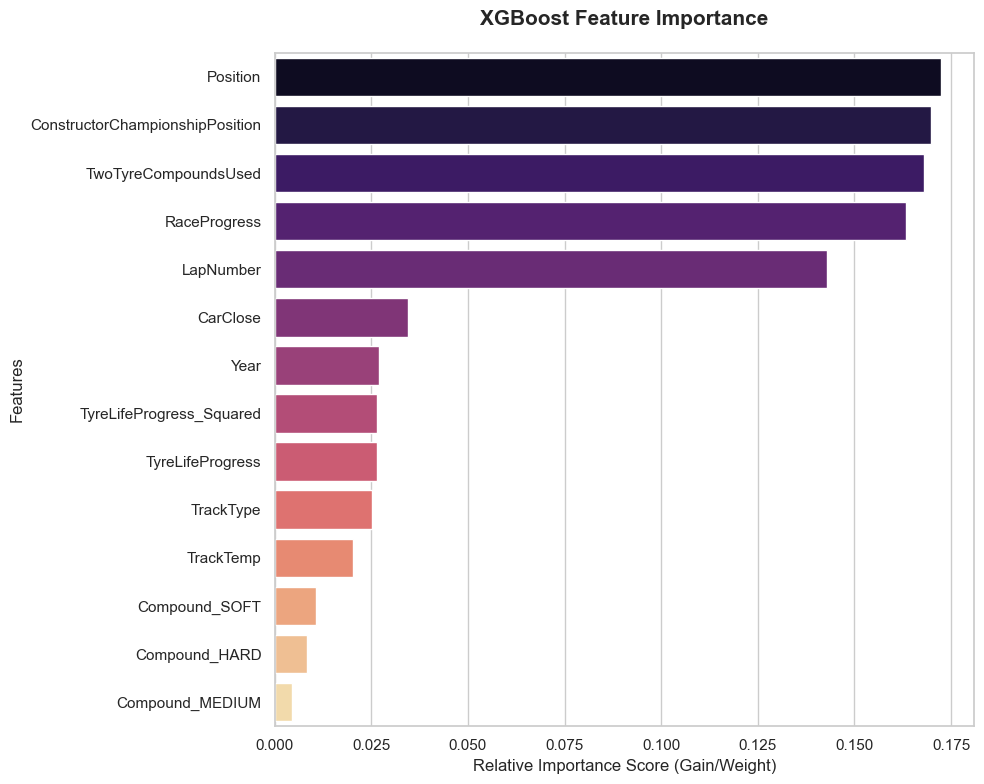


Top 5 Features for XGBoost Feature Importance:
                        Feature  Importance
                       Position    0.172320
ConstructorChampionshipPosition    0.169865
           TwoTyreCompoundsUsed    0.167909
                   RaceProgress    0.163426
                      LapNumber    0.142957


,Feature,Importance
0,Position,0.172320
1,ConstructorChampionshipPosition,0.169865
2,TwoTyreCompoundsUsed,0.167909
3,RaceProgress,0.163426
4,LapNumber,0.142957
5,CarClose,0.034593
6,Year,0.027032
7,TyreLifeProgress_Squared,0.026451
8,TyreLifeProgress,0.026396
9,TrackType,0.025106


In [9]:
plot_xgb_feature_importance(best_xgb_model, X_train_xgb_2.columns)

In [18]:
import xgboost as xgb
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# ---------------------------------------------------------
# DEFINE THE PARAMETER GRID
# ---------------------------------------------------------
# Sensible range for each hyperparameter.
param_distributions = {
    'learning_rate': [0.01, 0.02, 0.05, 0.1],
    'max_depth': [3, 4, 5, 6, 7],
    'min_child_weight': [1, 3, 5, 10],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'n_estimators': [800, 1000, 1200, 1300, 1400],
    'reg_lambda': [0.5, 1.0, 5.0],
    'reg_alpha': [0.0, 0.1, 0.5, 0.8]
}

# ---------------------------------------------------------
# INITIALIZE THE BASE MODEL
# ---------------------------------------------------------
xgb_base = xgb.XGBRegressor(
    objective='reg:squarederror',
    random_state=42,
)

# ---------------------------------------------------------
# SETUP RANDOMIZED SEARCH
# ---------------------------------------------------------
# We test 15 random combinations. Increase n_iter if you have time/CPU power!
random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_distributions,
    n_iter=25, 
    scoring='neg_mean_absolute_error', # We optimize specifically for MAE
    cv=3,                              # 3-Fold Cross Validation
    verbose=2,
    random_state=42,
    n_jobs=-1                          # Use all CPU cores for the search
)

# ---------------------------------------------------------
# RUN THE SEARCH
# ---------------------------------------------------------
print("🟢 Starting Randomized Search (Grab a coffee, this will take a few minutes)...")

# We use the combined Train + Validation set. 
# The 'cv=3' argument will automatically split it during the search.
random_search.fit(X_train_val_xgb_2, y_train_val_xgb_2)

# ---------------------------------------------------------
# PRINT THE BEST RESULTS
# ---------------------------------------------------------
print("\n✅ Search Completed!")
print(f"🏆 Best Parameters Found:\n{random_search.best_params_}")
print(f"📊 Best Cross-Validation MAE: {-random_search.best_score_:.3f} seconds")

# Retrieve the absolute best model from the search
best_xgb_model = random_search.best_estimator_

🟢 Starting Randomized Search (Grab a coffee, this will take a few minutes)...
Fitting 3 folds for each of 25 candidates, totalling 75 fits

✅ Search Completed!
🏆 Best Parameters Found:
{'subsample': 0.6, 'reg_lambda': 1.0, 'reg_alpha': 0.1, 'n_estimators': 1400, 'min_child_weight': 5, 'max_depth': 3, 'learning_rate': 0.01, 'colsample_bytree': 0.6}
📊 Best Cross-Validation MAE: 0.686 seconds


C:\Users\lucam\AppData\Local\Temp\ipykernel_8576\2530003335.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


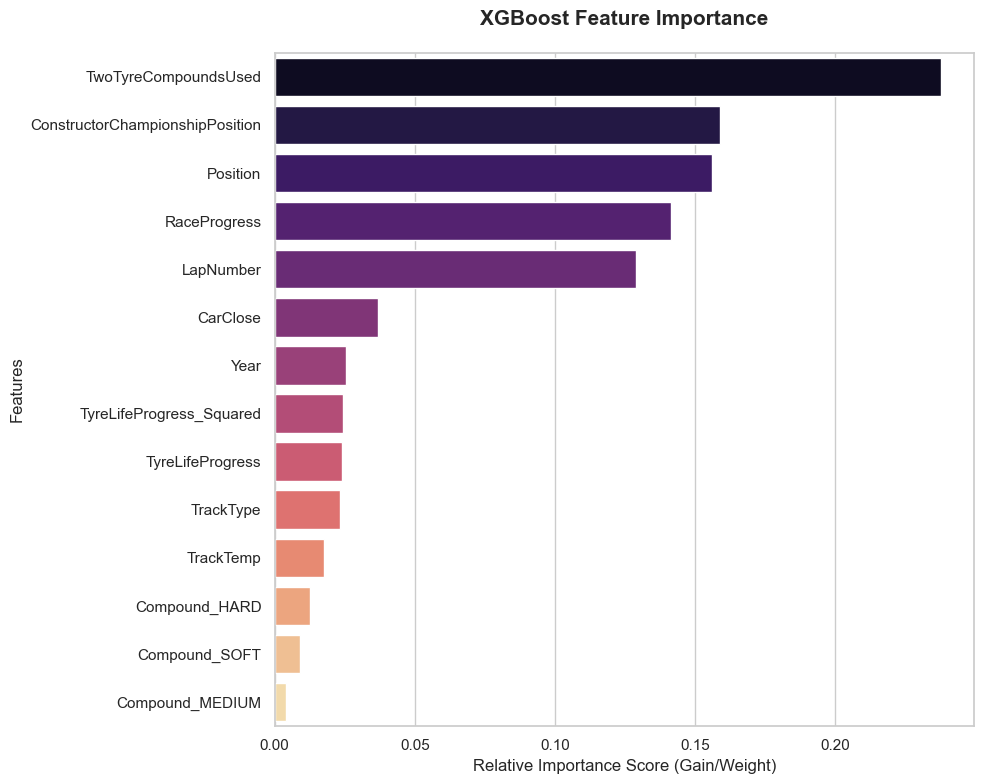


Top 5 Features for XGBoost Feature Importance:
                        Feature  Importance
           TwoTyreCompoundsUsed    0.237711
ConstructorChampionshipPosition    0.158991
                       Position    0.156040
                   RaceProgress    0.141607
                      LapNumber    0.128852


,Feature,Importance
0,TwoTyreCompoundsUsed,0.237711
1,ConstructorChampionshipPosition,0.158991
2,Position,0.156040
3,RaceProgress,0.141607
4,LapNumber,0.128852
5,CarClose,0.036812
6,Year,0.025280
7,TyreLifeProgress_Squared,0.024326
8,TyreLifeProgress,0.023907
9,TrackType,0.023345


In [19]:
plot_xgb_feature_importance(best_xgb_model, X_train_xgb_2.columns)

### SIMULATION

In [55]:
import tensorflow as tf
import joblib

# ---------------------------------------------------------
# LOAD THE NEURAL NETWORK MODEL V3
# ---------------------------------------------------------
# nn_model = tf.keras.models.load_model('f1_strategic_model_m10_v3.keras')
nn_model = tf.keras.models.load_model('f1_strategic_model_m10_v4.keras')


# ---------------------------------------------------------
# LOAD THE OPTIMIZED XGBOOST MODEL V4
# ---------------------------------------------------------
best_xgb_model = joblib.load('f1_pace_model_v6_optimized.joblib')

# Simulazione strategia dinamica con rischio Safety Car/VSC (Monte Carlo Expected Value)

In [56]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# ---------------------------------------------------------
# SPLIT DATA (Train, Validation, Test)
# ---------------------------------------------------------
# We use the most recent year in your dataset as the unseen Test Set (2025)
test_year = df_race['Year'].max()

# Create masks to separate the data
train_val_mask = df_race['Year'] < test_year
test_mask = df_race['Year'] == test_year

df_train_val_nn = df_race[train_val_mask].copy()
df_test_nn = df_race[test_mask].copy()

# Features for the neural network
nn_cols_to_keep = [
    'Position', 
    'TrackTemp', 
    'RaceProgress', 
    'TyreLifeProgress', 
    'CarClose', 
    'PitStopBehind', 
    'TwoTyreCompoundsUsed', 
    'TrackType', 
    'ConstructorChampionshipPosition', 
    'Compound_HARD', 
    'Compound_MEDIUM', 
    'Compound_SOFT', 
    'CleanTrackStatus_GreenFlag', 
    'CleanTrackStatus_RedFlag', 
    'CleanTrackStatus_SafetyCar', 
    'CleanTrackStatus_VSC', 
    'CleanTrackStatus_YellowFlag'
]

X_train_val_nn = df_train_val_nn[nn_cols_to_keep]
y_train_val_nn = df_train_val_nn['InPits']

X_test_nn = df_test_nn[nn_cols_to_keep]
y_test_nn = df_test_nn['InPits']

# Split the historical data into Train (80%) and Validation (20%)
# stratify=y_train_val ensures both sets have the same ~3% ratio of pit stops
X_train_nn, X_valid_nn, y_train_nn, y_valid_nn = train_test_split(
    X_train_val_nn, y_train_val_nn,
    test_size=0.2, 
    random_state=42, 
    stratify=y_train_val_nn
)

print(f"Features ready for the Neural Network: {X_train_nn.shape[1]}")
print(f"Train samples: {X_train_nn.shape[0]} | Validation samples: {X_valid_nn.shape[0]} | Test samples: {X_test_nn.shape[0]}")

Features ready for the Neural Network: 17
Train samples: 75192 | Validation samples: 18799 | Test samples: 17824


In [59]:
nn_features = X_train_nn.columns.tolist()
xgb_features = X_train_xgb_2.columns.tolist()

In [60]:
# =====================================================================
# 4. SAFETY CAR / VSC PROBABILITY MATRIX (STOCHASTIC BINNING)
# =====================================================================
# We divide the race into 20 segments (bins) of 5% RaceProgress each.
# This identifies "High Risk" zones (e.g., Start, Pit Windows).
bins = np.arange(0, 1.05, 0.05)
df_race['ProgressBin'] = pd.cut(df_race['RaceProgress'], bins=bins)

# Calculate the mean frequency of neutralizations per bin
sc_prob_matrix = df_race.groupby('ProgressBin', observed=False)[['CleanTrackStatus_SafetyCar', 'CleanTrackStatus_VSC']].mean()
# Combined probability for any track neutralization
sc_prob_matrix['Neutralization_Prob'] = sc_prob_matrix['CleanTrackStatus_SafetyCar'] + sc_prob_matrix['CleanTrackStatus_VSC']

print("🚨 Top 5 High-Risk Race Segments (Safety Car/VSC Probability):")
print(sc_prob_matrix['Neutralization_Prob'].sort_values(ascending=False).head(5))

🚨 Top 5 High-Risk Race Segments (Safety Car/VSC Probability):
ProgressBin
(0.0, 0.05]    0.151854
(0.75, 0.8]    0.090011
(0.7, 0.75]    0.077547
(0.8, 0.85]    0.067345
(0.9, 0.95]    0.066606
Name: Neutralization_Prob, dtype: float64


In [61]:
import pandas as pd
import numpy as np
import copy

def run_stochastic_dynamic_strategy_test(df_master, gp_name, driver_code, year, nn_model, xgb_model, xgb_features, nn_features, sc_prob_matrix):
    """
    Simulazione Monte Carlo (Expected Value) della strategia F1.
    L'IA non conosce il futuro, ma calcola il rischio statistico di Safety Car/VSC.
    Include Veto di Rete Neurale, Bonus Reazione Rapida e XAI (Explainability).
    """
    driver_col = f'Driver_{driver_code}'
    race_data = df_master[(df_master['GP'] == gp_name) & 
                          (df_master['Year'] == year) & 
                          (df_master[driver_col] == 1)].sort_values('LapNumber').copy()
    
    if race_data.empty: return None

    # ==========================================
    # ⚙️ COSTANTI STRATEGICHE (HARDCODED)
    # ==========================================
    # CLIFF_LAPS = {'SOFT': 22, 'MEDIUM': 38, 'HARD': 55} 
    CLIFF_LAPS = {'SOFT': 28, 'MEDIUM': 40, 'HARD': 50}    
    NORMAL_PIT_LOSS = 24.0
    SC_PIT_LOSS = 14.0
    MAX_TYRE_LIFE = 40.0
    NN_PIT_THRESHOLD = 0.45 
    NN_VETO_THRESHOLD = 0.70 # SOGLIA VETO
    SC_AVERAGE_LAPS = 3 
    
    prob_dict = {interval: prob for interval, prob in sc_prob_matrix['Neutralization_Prob'].items()}

    start_comp = 'MEDIUM'
    if race_data.iloc[0]['Compound_SOFT'] == 1: start_comp = 'SOFT'
    elif race_data.iloc[0]['Compound_HARD'] == 1: start_comp = 'HARD'

    prediction_cache = {}

    def evaluate_action_to_finish(start_idx, base_state, action_this_lap, sc_active_now, is_new_sc):
        state = copy.deepcopy(base_state)
        projected_time = 0.0
        
        # 1. AZIONE IMMEDIATA
        if "BOX" in action_this_lap:
            new_comp = action_this_lap.split("_")[1]
            if sc_active_now:
                pit_cost = (SC_PIT_LOSS - 2.0) if is_new_sc else SC_PIT_LOSS
            else:
                pit_cost = NORMAL_PIT_LOSS
                
            projected_time += pit_cost
            state['current_compound'] = new_comp
            state['tyre_age'] = 0
            state['compounds_used'].add(new_comp)
        
        simulated_sc_laps_left = SC_AVERAGE_LAPS if sc_active_now else 0

        # 2. PROIEZIONE "CIECA" SUL FUTURO
        for j in range(start_idx, len(race_data)):
            has_two_comps = 1 if len(state['compounds_used']) > 1 else 0
            current_progress = race_data.iloc[j]['RaceProgress']
            
            if simulated_sc_laps_left > 0:
                sc_probability = 1.0
                simulated_sc_laps_left -= 1
            else:
                sc_probability = 0.05 
                for interval, prob in prob_dict.items():
                    if current_progress in interval:
                        sc_probability = prob
                        break
            
            cache_key = (j, state['tyre_age'], state['current_compound'], has_two_comps)
            if cache_key in prediction_cache:
                base_pace, nn_prob = prediction_cache[cache_key]
            else:
                lap_df = race_data.iloc[[j]].copy()
                lap_df['CleanTrackStatus_SafetyCar'] = 0
                lap_df['CleanTrackStatus_VSC'] = 0
                
                tyre_prog = state['tyre_age'] / MAX_TYRE_LIFE
                lap_df['TyreLifeProgress'] = tyre_prog
                lap_df['TyreLifeProgress_Squared'] = tyre_prog ** 2
                lap_df['Compound_SOFT'] = 1 if state['current_compound'] == 'SOFT' else 0
                lap_df['Compound_MEDIUM'] = 1 if state['current_compound'] == 'MEDIUM' else 0
                lap_df['Compound_HARD'] = 1 if state['current_compound'] == 'HARD' else 0
                lap_df['TwoTyreCompoundsUsed'] = has_two_comps
                
                base_pace = xgb_model.predict(lap_df[xgb_features])[0]
                nn_prob = nn_model.predict(lap_df[nn_features], verbose=0)[0][0]
                prediction_cache[cache_key] = (base_pace, nn_prob)

            if state['tyre_age'] <= 1:
                base_pace = min(base_pace, 3.0)
                
            pace_if_green = base_pace
            pace_if_sc = base_pace + 35.0 
            
            expected_pace = (pace_if_green * (1 - sc_probability)) + (pace_if_sc * sc_probability)
            projected_time += expected_pace
            
            if state['tyre_age'] > CLIFF_LAPS[state['current_compound']]:
                projected_time += (state['tyre_age'] - CLIFF_LAPS[state['current_compound']]) * 2.5
                
            if nn_prob > NN_PIT_THRESHOLD or state['tyre_age'] >= CLIFF_LAPS[state['current_compound']]:
                expected_pit_cost = (NORMAL_PIT_LOSS * (1 - sc_probability)) + (SC_PIT_LOSS * sc_probability)
                projected_time += expected_pit_cost
                
                #next_comp = 'HARD' if 'HARD' not in state['compounds_used'] else 'MEDIUM'
                remaining = [c for c in ['HARD', 'MEDIUM', 'SOFT'] 
                             if c not in state['compounds_used'] 
                             and c != state['current_compound']]
                next_comp = remaining[0] if remaining else ('MEDIUM' if state['current_compound'] != 'MEDIUM' else 'HARD')

                state['current_compound'] = next_comp
                state['tyre_age'] = 0
                state['compounds_used'].add(next_comp)
            else:
                state['tyre_age'] += 1
                
        if len(state['compounds_used']) < 2: projected_time += 999.0 
        
        return projected_time

    # ---------------------------------------------------------
    # REALITY: IL CICLO DELLA GARA VERA
    # ---------------------------------------------------------
    real_state = {
        'current_compound': start_comp,
        'tyre_age': 0,
        'compounds_used': {start_comp}
    }
    
    simulation_logs = []
    
    print(f"\n🟢 INIZIO GARA: {gp_name} ({year}) | Pilota: {driver_code} | Mescola Partenza: {start_comp}")
    print("-" * 60)
    
    for i in range(len(race_data)):
        lap_df = race_data.iloc[[i]].copy()
        lap_num = int(lap_df['LapNumber'].iloc[0])

        is_sc = int(lap_df['CleanTrackStatus_SafetyCar'].iloc[0]) == 1
        is_vsc = int(lap_df['CleanTrackStatus_VSC'].iloc[0]) == 1
        is_sc_now = is_sc or is_vsc
        
        was_sc_prev = False
        if i > 0:
            prev_lap = race_data.iloc[[i-1]]
            was_sc_prev = int(prev_lap['CleanTrackStatus_SafetyCar'].iloc[0]) == 1 or int(prev_lap['CleanTrackStatus_VSC'].iloc[0]) == 1
        is_new_sc = is_sc_now and not was_sc_prev
        
        # Calcolo rischio SC per telemetria estesa
        current_progress = lap_df['RaceProgress'].iloc[0]
        current_sc_prob = 0.05
        for interval, prob in prob_dict.items():
            if current_progress in interval:
                current_sc_prob = prob
                break
        
        tyre_prog = real_state['tyre_age'] / MAX_TYRE_LIFE
        lap_df['TyreLifeProgress'] = tyre_prog
        lap_df['TyreLifeProgress_Squared'] = tyre_prog ** 2
        lap_df['Compound_SOFT'] = 1 if real_state['current_compound'] == 'SOFT' else 0
        lap_df['Compound_MEDIUM'] = 1 if real_state['current_compound'] == 'MEDIUM' else 0
        lap_df['Compound_HARD'] = 1 if real_state['current_compound'] == 'HARD' else 0
        lap_df['TwoTyreCompoundsUsed'] = 1 if len(real_state['compounds_used']) > 1 else 0
        
        base_current_pace = xgb_model.predict(lap_df[xgb_features])[0]

        if real_state['tyre_age'] <= 1:
            base_current_pace = min(base_current_pace, 3.0)

        current_pace_delta = base_current_pace
        if is_sc:
            current_pace_delta += 45.0
        elif is_vsc:
            current_pace_delta += 25.0

        current_pit_prob = nn_model.predict(lap_df[nn_features], verbose=0)[0][0]

        options = ["STAY_OUT"]
        if real_state['tyre_age'] > 6 or (is_sc_now and real_state['tyre_age'] > 3):
            for comp in ['SOFT', 'MEDIUM', 'HARD']:
                if comp != real_state['current_compound']:
                    options.append(f"BOX_{comp}")
        
        veto_activated = False
        if is_sc_now and current_pit_prob >= NN_VETO_THRESHOLD and len(options) > 1:
            options.remove("STAY_OUT")
            veto_activated = True
                    
        evaluations = {}
        best_option = options[0] 
        best_time = float('inf')
        
        for opt in options:
            proj_time = evaluate_action_to_finish(i, real_state, opt, is_sc_now, is_new_sc)
            evaluations[opt] = proj_time
            if proj_time < best_time:
                best_time = proj_time
                best_option = opt

        tyre_age_for_log = real_state['tyre_age']       # ← snapshot PRIMA
        compound_for_log = real_state['current_compound'] # ← snapshot PRIMA

        action_taken = "STAY OUT"
        if "BOX" in best_option:
            chosen_comp = best_option.split("_")[1]
            sc_tag = " (SAFETY CAR)" if is_sc_now else " (STRATEGY)"
            action_taken = f"BOX{sc_tag}"
            
            real_state['current_compound'] = chosen_comp
            real_state['tyre_age'] = 0
            real_state['compounds_used'].add(chosen_comp)
        else:
            real_state['tyre_age'] += 1

        # ==========================================================
        # 🟢 MODIFICA 3: TEAM RADIO (Log Eventi Critici in Console)
        # ==========================================================
        if is_new_sc or current_pit_prob > 0.40 or "BOX" in action_taken:
            print(f"\n[LAP {lap_num}] 📻 TEAM RADIO")
            if is_new_sc:
                print("   🟡 SAFETY CAR / VSC DEPLOYED!")
            if veto_activated:
                print(f"   🚨 NN VETO ACTIVATED (Prob: {current_pit_prob:.2f}) - STAY OUT scartato per difesa!")
            elif current_pit_prob > 0.40:
                print(f"   🧠 Alert Rete Neurale: Probabilità Pit Stop al {current_pit_prob:.2f}")
            
            # Formattiamo le valutazioni di tempo
            eval_str = " | ".join([f"{k}: {v:.1f}s" for k, v in evaluations.items()])
            print(f"   📊 Valutazione IA: {eval_str}")
            print(f"   👉 Decisione Presa: {action_taken}")

        # ==========================================================
        # 🟢 MODIFICA 4: TELEMETRIA ESTESA (Aggiunta al DataFrame)
        # ==========================================================
        simulation_logs.append({
            'Lap': lap_num,
            'Sim_TyreAge_StartOfLap': tyre_age_for_log,
            'Sim_Compound': compound_for_log,
            'AI_Pace_Delta': current_pace_delta,
            'AI_Pit_Prob': current_pit_prob,
            'Action': action_taken,
            # Dati aggiuntivi (Explainability XAI)
            'Time_If_Stay_Out': evaluations.get('STAY_OUT', None),
            'Time_If_Box_Soft': evaluations.get('BOX_SOFT', None),
            'Time_If_Box_Medium': evaluations.get('BOX_MEDIUM', None),
            'Time_If_Box_Hard': evaluations.get('BOX_HARD', None),
            'SC_Risk_Prob': current_sc_prob
        })

    print("-" * 60)
    print("🏁 GARA TERMINATA.")
    return pd.DataFrame(simulation_logs)

In [65]:
import matplotlib.patches as mpatches
import seaborn as sns

def plot_simulation_vs_reality_v2(sim_df, real_df, driver_code, gp_name, year):
    """
    Dashboard avanzata: Confronto Pace, Probabilità, Safety Car e Gomme Simulate.
    """
    # Impostazione tema
    sns.set_theme(style="whitegrid")
    fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(14, 10), sharex=True)
    fig.suptitle(f"AI STRATEGY DASHBOARD: {driver_code} @ {gp_name} ({year})", 
                 fontsize=18, fontweight='bold')

    # 1. PREPARAZIONE COLORI GOMME SIMULATE
    def get_comp_color(compound):
        if 'SOFT' in str(compound).upper(): return '#FF3333'
        if 'MEDIUM' in str(compound).upper(): return '#EBEB00'
        if 'HARD' in str(compound).upper(): return '#A6A6A6'
        return 'cyan'

    sim_df['Color'] = sim_df['Sim_Compound'].apply(get_comp_color)

    # ---------------------------------------------------------
    # BACKGOUND: SAFETY CAR / VSC
    # ---------------------------------------------------------
    # Data from the real race
    track_status = real_df[['LapNumber', 'CleanTrackStatus_SafetyCar', 'CleanTrackStatus_VSC', 'CleanTrackStatus_RedFlag']].drop_duplicates()
    
    for _, row in track_status.iterrows():
        lap = row['LapNumber']
        color = None
        if row['CleanTrackStatus_RedFlag'] == 1: color, alpha = 'red', 0.15
        elif row['CleanTrackStatus_SafetyCar'] == 1: color, alpha = 'orange', 0.15
        elif row['CleanTrackStatus_VSC'] == 1: color, alpha = 'gold', 0.15
        
        if color:
            ax1.axvspan(lap - 0.5, lap + 0.5, color=color, alpha=alpha, lw=0)
            ax2.axvspan(lap - 0.5, lap + 0.5, color=color, alpha=alpha, lw=0)

    # ---------------------------------------------------------
    # TOP PLOT: Pace Delta & Simulated Compounds
    # ---------------------------------------------------------
    # AI pace
    sns.lineplot(data=sim_df, x='Lap', y='AI_Pace_Delta', ax=ax1, 
                 color='#1f77b4', linewidth=2.5, label='AI Predicted Pace')
    
    # Scatter points for AI tyres
    ax1.scatter(sim_df['Lap'], sim_df['AI_Pace_Delta'], c=sim_df['Color'], 
                s=40, edgecolor='black', linewidth=0.5, zorder=3, label='Simulated Compound')

    # Real World Pace (Actual)
    real_pace_clean = real_df[real_df['LapDeltaSeconds'] < 10.0]
    sns.scatterplot(data=real_pace_clean, x='LapNumber', y='LapDeltaSeconds', ax=ax1,
                    color='gray', alpha=0.3, s=20, label='Real Pace (Actual)', zorder=2)
    
    ax1.set_title("Race Pace & Simulated Tyre Compounds", fontsize=14, fontweight='bold')
    ax1.set_ylabel("Delta vs Baseline (s)")

   # Find the "normal" AI maximum, excluding huge SC peaks (> 15s)
    normal_sim_pace = sim_df[sim_df['AI_Pace_Delta'] < 15.0]['AI_Pace_Delta']
    sim_max = normal_sim_pace.max() if not normal_sim_pace.empty else 5.0
    sim_min = sim_df['AI_Pace_Delta'].min()

    # Find the real limits (which you had already cleaned below 10.0s)
    real_max = real_pace_clean['LapDeltaSeconds'].max() if not real_pace_clean.empty else 5.0
    real_min = real_pace_clean['LapDeltaSeconds'].min() if not real_pace_clean.empty else -1.0

    # Calculate the limits and force a "Maximum Ceiling" (e.g., 8 or 10 seconds)
    # This way, the chart will never go beyond 10 seconds in height
    y_max_calculated = max(sim_max, real_max) + 1.5
    y_max = min(y_max_calculated, 10.0)
    
    y_min = min(sim_min, real_min) - 0.5
    
    ax1.set_ylim(y_min, y_max)

    # ---------------------------------------------------------
    # BOTTOM PLOT: Neural Network Probability
    # ---------------------------------------------------------
    sns.lineplot(data=sim_df, x='Lap', y='AI_Pit_Prob', ax=ax2, 
                 color='#d62728', linewidth=2.5, label='AI Pit Probability', zorder=3)
    
    ax2.axhline(y=0.45, color='darkorange', linestyle='--', linewidth=1.5, label='Decision Threshold (0.45)')
    
    ax2.set_title("Strategic Confidence (Neural Network)", fontsize=14, fontweight='bold')
    ax2.set_ylabel("Probability")
    ax2.set_xlabel("Lap Number")
    ax2.set_ylim(-0.05, 1.05)

    # ---------------------------------------------------------
    # PIT STOP (AI vs REAL)
    # ---------------------------------------------------------
    # AI Pit Stops
    ai_pit_laps = sim_df[sim_df['Action'].str.contains("BOX")]['Lap'].tolist()
    for pit_lap in ai_pit_laps:
        ax1.axvline(x=pit_lap, color='black', linestyle='-.', linewidth=1.5, alpha=0.7)
        ax1.text(pit_lap + 0.3, ax1.get_ylim()[1] * 0.9, 'AI BOX', color='black', fontsize=9, fontweight='bold', rotation=90)
        ax2.axvline(x=pit_lap, color='black', linestyle='-.', linewidth=1.5, alpha=0.7)

    # Real Pit Stops
    real_pit_laps = real_df[real_df['InPits'] == 1]['LapNumber'].tolist()
    for pit_lap in real_pit_laps:
        ax1.axvline(x=pit_lap, color='green', linestyle=':', linewidth=2, alpha=0.8)
        ax1.text(pit_lap - 0.8, ax1.get_ylim()[1] * 0.9, 'REAL BOX', color='green', fontsize=9, fontweight='bold', rotation=90)
        ax2.axvline(x=pit_lap, color='green', linestyle=':', linewidth=2, alpha=0.8)

    # ---------------------------------------------------------
    # CUSTOM LEGENDA
    # ---------------------------------------------------------
    legend_elements = [
        mpatches.Patch(color='orange', alpha=0.3, label='Safety Car Window'),
        mpatches.Patch(color='gold', alpha=0.3, label='=VSC Window'),
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#FF3333', markersize=10, markeredgecolor='k', label='Simulated Soft'),
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#EBEB00', markersize=10, markeredgecolor='k', label='Simulated Medium'),
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#A6A6A6', markersize=10, markeredgecolor='k', label='Simulated Hard'),
        plt.Line2D([0], [0], color='black', linestyle='-.', label='AI Decision'),
        plt.Line2D([0], [0], color='green', linestyle=':', label='Real Historical Pit')
    ]
    ax1.legend(handles=legend_elements, loc='upper right', fontsize=9, frameon=True)

    plt.tight_layout()
    plt.show()

In [66]:
import pandas as pd
import numpy as np
import copy

def run_stochastic_dynamic_strategy_test_year(df_master, gp_name, driver_code, year, nn_model, xgb_model, xgb_features, nn_features, sc_prob_matrix):
    """
    Simulazione Monte Carlo (Expected Value) della strategia F1.
    L'IA non conosce il futuro, ma calcola il rischio statistico di Safety Car/VSC.
    Include Veto di Rete Neurale, Bonus Reazione Rapida e XAI (Explainability).
    """
    driver_col = f'Driver_{driver_code}'
    race_data = df_master[(df_master['GP'] == gp_name) & 
                          (df_master['Year'] == year) & 
                          (df_master[driver_col] == 1)].sort_values('LapNumber').copy()
    
    if race_data.empty: return None

    # ==========================================
    # ⚙️ COSTANTI STRATEGICHE (HARDCODED)
    # ==========================================
    # CLIFF_LAPS = {'SOFT': 22, 'MEDIUM': 38, 'HARD': 55} 
    CLIFF_LAPS = {'SOFT': 28, 'MEDIUM': 40, 'HARD': 50}    
    NORMAL_PIT_LOSS = 24.0
    SC_PIT_LOSS = 14.0
    MAX_TYRE_LIFE = 40.0
    NN_PIT_THRESHOLD = 0.45 
    NN_VETO_THRESHOLD = 0.70 # SOGLIA VETO
    SC_AVERAGE_LAPS = 3 
    
    prob_dict = {interval: prob for interval, prob in sc_prob_matrix['Neutralization_Prob'].items()}

    start_comp = 'MEDIUM'
    if race_data.iloc[0]['Compound_SOFT'] == 1: start_comp = 'SOFT'
    elif race_data.iloc[0]['Compound_HARD'] == 1: start_comp = 'HARD'

    prediction_cache = {}

    def evaluate_action_to_finish(start_idx, base_state, action_this_lap, sc_active_now, is_new_sc):
        state = copy.deepcopy(base_state)
        projected_time = 0.0
        
        # 1. AZIONE IMMEDIATA
        if "BOX" in action_this_lap:
            new_comp = action_this_lap.split("_")[1]
            if sc_active_now:
                pit_cost = (SC_PIT_LOSS - 2.0) if is_new_sc else SC_PIT_LOSS
            else:
                pit_cost = NORMAL_PIT_LOSS
                
            projected_time += pit_cost
            state['current_compound'] = new_comp
            state['tyre_age'] = 0
            state['compounds_used'].add(new_comp)
        
        simulated_sc_laps_left = SC_AVERAGE_LAPS if sc_active_now else 0

        # 2. PROIEZIONE "CIECA" SUL FUTURO
        for j in range(start_idx, len(race_data)):
            has_two_comps = 1 if len(state['compounds_used']) > 1 else 0
            current_progress = race_data.iloc[j]['RaceProgress']
            
            if simulated_sc_laps_left > 0:
                sc_probability = 1.0
                simulated_sc_laps_left -= 1
            else:
                sc_probability = 0.05 
                for interval, prob in prob_dict.items():
                    if current_progress in interval:
                        sc_probability = prob
                        break
            
            cache_key = (j, state['tyre_age'], state['current_compound'], has_two_comps)
            if cache_key in prediction_cache:
                base_pace, nn_prob = prediction_cache[cache_key]
            else:
                lap_df = race_data.iloc[[j]].copy()
                lap_df['CleanTrackStatus_SafetyCar'] = 0
                lap_df['CleanTrackStatus_VSC'] = 0
                
                tyre_prog = state['tyre_age'] / MAX_TYRE_LIFE
                lap_df['TyreLifeProgress'] = tyre_prog
                lap_df['TyreLifeProgress_Squared'] = tyre_prog ** 2
                lap_df['Compound_SOFT'] = 1 if state['current_compound'] == 'SOFT' else 0
                lap_df['Compound_MEDIUM'] = 1 if state['current_compound'] == 'MEDIUM' else 0
                lap_df['Compound_HARD'] = 1 if state['current_compound'] == 'HARD' else 0
                lap_df['TwoTyreCompoundsUsed'] = has_two_comps
                lap_df['Year'] = year
                lap_df['ConstructorChampionshipPosition'] = race_data['ConstructorChampionshipPosition'].iloc[0]
                
                base_pace = xgb_model.predict(lap_df[xgb_features])[0]
                nn_prob = nn_model.predict(lap_df[nn_features], verbose=0)[0][0]
                prediction_cache[cache_key] = (base_pace, nn_prob)

            if state['tyre_age'] <= 1:
                base_pace = min(base_pace, 3.0)
                
            pace_if_green = base_pace
            pace_if_sc = base_pace + 35.0 
            
            expected_pace = (pace_if_green * (1 - sc_probability)) + (pace_if_sc * sc_probability)
            projected_time += expected_pace
            
            if state['tyre_age'] > CLIFF_LAPS[state['current_compound']]:
                projected_time += (state['tyre_age'] - CLIFF_LAPS[state['current_compound']]) * 2.5
                
            if nn_prob > NN_PIT_THRESHOLD or state['tyre_age'] >= CLIFF_LAPS[state['current_compound']]:
                expected_pit_cost = (NORMAL_PIT_LOSS * (1 - sc_probability)) + (SC_PIT_LOSS * sc_probability)
                projected_time += expected_pit_cost
                
                #next_comp = 'HARD' if 'HARD' not in state['compounds_used'] else 'MEDIUM'
                remaining = [c for c in ['HARD', 'MEDIUM', 'SOFT'] 
                             if c not in state['compounds_used'] 
                             and c != state['current_compound']]
                next_comp = remaining[0] if remaining else ('MEDIUM' if state['current_compound'] != 'MEDIUM' else 'HARD')

                state['current_compound'] = next_comp
                state['tyre_age'] = 0
                state['compounds_used'].add(next_comp)
            else:
                state['tyre_age'] += 1
                
        if len(state['compounds_used']) < 2: projected_time += 999.0 
        
        return projected_time

    # ---------------------------------------------------------
    # REALITY: IL CICLO DELLA GARA VERA
    # ---------------------------------------------------------
    real_state = {
        'current_compound': start_comp,
        'tyre_age': 0,
        'compounds_used': {start_comp}
    }
    
    simulation_logs = []
    
    print(f"\n🟢 INIZIO GARA: {gp_name} ({year}) | Pilota: {driver_code} | Mescola Partenza: {start_comp}")
    print("-" * 60)
    
    for i in range(len(race_data)):
        lap_df = race_data.iloc[[i]].copy()
        lap_num = int(lap_df['LapNumber'].iloc[0])

        is_sc = int(lap_df['CleanTrackStatus_SafetyCar'].iloc[0]) == 1
        is_vsc = int(lap_df['CleanTrackStatus_VSC'].iloc[0]) == 1
        is_sc_now = is_sc or is_vsc
        
        was_sc_prev = False
        if i > 0:
            prev_lap = race_data.iloc[[i-1]]
            was_sc_prev = int(prev_lap['CleanTrackStatus_SafetyCar'].iloc[0]) == 1 or int(prev_lap['CleanTrackStatus_VSC'].iloc[0]) == 1
        is_new_sc = is_sc_now and not was_sc_prev
        
        # Calcolo rischio SC per telemetria estesa
        current_progress = lap_df['RaceProgress'].iloc[0]
        current_sc_prob = 0.05
        for interval, prob in prob_dict.items():
            if current_progress in interval:
                current_sc_prob = prob
                break
        
        tyre_prog = real_state['tyre_age'] / MAX_TYRE_LIFE
        lap_df['TyreLifeProgress'] = tyre_prog
        lap_df['TyreLifeProgress_Squared'] = tyre_prog ** 2
        lap_df['Compound_SOFT'] = 1 if real_state['current_compound'] == 'SOFT' else 0
        lap_df['Compound_MEDIUM'] = 1 if real_state['current_compound'] == 'MEDIUM' else 0
        lap_df['Compound_HARD'] = 1 if real_state['current_compound'] == 'HARD' else 0
        lap_df['TwoTyreCompoundsUsed'] = 1 if len(real_state['compounds_used']) > 1 else 0
        lap_df['Year'] = year
        lap_df['ConstructorChampionshipPosition'] = race_data['ConstructorChampionshipPosition'].iloc[0]

        
        base_current_pace = xgb_model.predict(lap_df[xgb_features])[0]

        if real_state['tyre_age'] <= 1:
            base_current_pace = min(base_current_pace, 3.0)

        current_pace_delta = base_current_pace
        if is_sc:
            current_pace_delta += 45.0
        elif is_vsc:
            current_pace_delta += 25.0

        current_pit_prob = nn_model.predict(lap_df[nn_features], verbose=0)[0][0]

        options = ["STAY_OUT"]
        if real_state['tyre_age'] > 6 or (is_sc_now and real_state['tyre_age'] > 3):
            for comp in ['SOFT', 'MEDIUM', 'HARD']:
                if comp != real_state['current_compound']:
                    options.append(f"BOX_{comp}")
        
        veto_activated = False
        if is_sc_now and current_pit_prob >= NN_VETO_THRESHOLD and len(options) > 1:
            options.remove("STAY_OUT")
            veto_activated = True
                    
        evaluations = {}
        best_option = options[0] 
        best_time = float('inf')
        
        for opt in options:
            proj_time = evaluate_action_to_finish(i, real_state, opt, is_sc_now, is_new_sc)
            evaluations[opt] = proj_time
            if proj_time < best_time:
                best_time = proj_time
                best_option = opt

        tyre_age_for_log = real_state['tyre_age']       # ← snapshot PRIMA
        compound_for_log = real_state['current_compound'] # ← snapshot PRIMA

        action_taken = "STAY OUT"
        if "BOX" in best_option:
            chosen_comp = best_option.split("_")[1]
            sc_tag = " (SAFETY CAR)" if is_sc_now else " (STRATEGY)"
            action_taken = f"BOX{sc_tag}"
            
            real_state['current_compound'] = chosen_comp
            real_state['tyre_age'] = 0
            real_state['compounds_used'].add(chosen_comp)
        else:
            real_state['tyre_age'] += 1

        # ==========================================================
        # 🟢 MODIFICA 3: TEAM RADIO (Log Eventi Critici in Console)
        # ==========================================================
        if is_new_sc or current_pit_prob > 0.40 or "BOX" in action_taken:
            print(f"\n[LAP {lap_num}] 📻 TEAM RADIO")
            if is_new_sc:
                print("   🟡 SAFETY CAR / VSC DEPLOYED!")
            if veto_activated:
                print(f"   🚨 NN VETO ACTIVATED (Prob: {current_pit_prob:.2f}) - STAY OUT scartato per difesa!")
            elif current_pit_prob > 0.40:
                print(f"   🧠 Alert Rete Neurale: Probabilità Pit Stop al {current_pit_prob:.2f}")
            
            # Formattiamo le valutazioni di tempo
            eval_str = " | ".join([f"{k}: {v:.1f}s" for k, v in evaluations.items()])
            print(f"   📊 Valutazione IA: {eval_str}")
            print(f"   👉 Decisione Presa: {action_taken}")

        # ==========================================================
        # 🟢 MODIFICA 4: TELEMETRIA ESTESA (Aggiunta al DataFrame)
        # ==========================================================
        simulation_logs.append({
            'Lap': lap_num,
            'Sim_TyreAge_StartOfLap': tyre_age_for_log,
            'Sim_Compound': compound_for_log,
            'AI_Pace_Delta': current_pace_delta,
            'AI_Pit_Prob': current_pit_prob,
            'Action': action_taken,
            # Dati aggiuntivi (Explainability XAI)
            'Time_If_Stay_Out': evaluations.get('STAY_OUT', None),
            'Time_If_Box_Soft': evaluations.get('BOX_SOFT', None),
            'Time_If_Box_Medium': evaluations.get('BOX_MEDIUM', None),
            'Time_If_Box_Hard': evaluations.get('BOX_HARD', None),
            'SC_Risk_Prob': current_sc_prob
        })

    print("-" * 60)
    print("🏁 GARA TERMINATA.")
    return pd.DataFrame(simulation_logs)

🏁 Trovate le gare nell'intervallo scelto (3 - 5):
['Dutch Grand Prix', 'Emilia Romagna Grand Prix']
🏁 INIZIO TEST GLOBALE SU 2 GRAN PREMI...

⏳ Calcolando strategia per: Dutch Grand Prix...

🟢 INIZIO GARA: Dutch Grand Prix (2025) | Pilota: VER | Mescola Partenza: SOFT
------------------------------------------------------------

[LAP 21] 📻 TEAM RADIO
   📊 Valutazione IA: STAY_OUT: 181.2s | BOX_MEDIUM: 186.9s | BOX_HARD: 180.9s
   👉 Decisione Presa: BOX (STRATEGY)

[LAP 23] 📻 TEAM RADIO
   🟡 SAFETY CAR / VSC DEPLOYED!
   📊 Valutazione IA: STAY_OUT: 251.1s
   👉 Decisione Presa: STAY OUT

[LAP 31] 📻 TEAM RADIO
   🟡 SAFETY CAR / VSC DEPLOYED!
   📊 Valutazione IA: STAY_OUT: 229.8s | BOX_SOFT: 237.8s | BOX_MEDIUM: 257.3s
   👉 Decisione Presa: STAY OUT

[LAP 42] 📻 TEAM RADIO
   🧠 Alert Rete Neurale: Probabilità Pit Stop al 0.42
   📊 Valutazione IA: STAY_OUT: 105.7s | BOX_SOFT: 126.9s | BOX_MEDIUM: 107.2s
   👉 Decisione Presa: STAY OUT

[LAP 43] 📻 TEAM RADIO
   🧠 Alert Rete Neurale: Probabilit

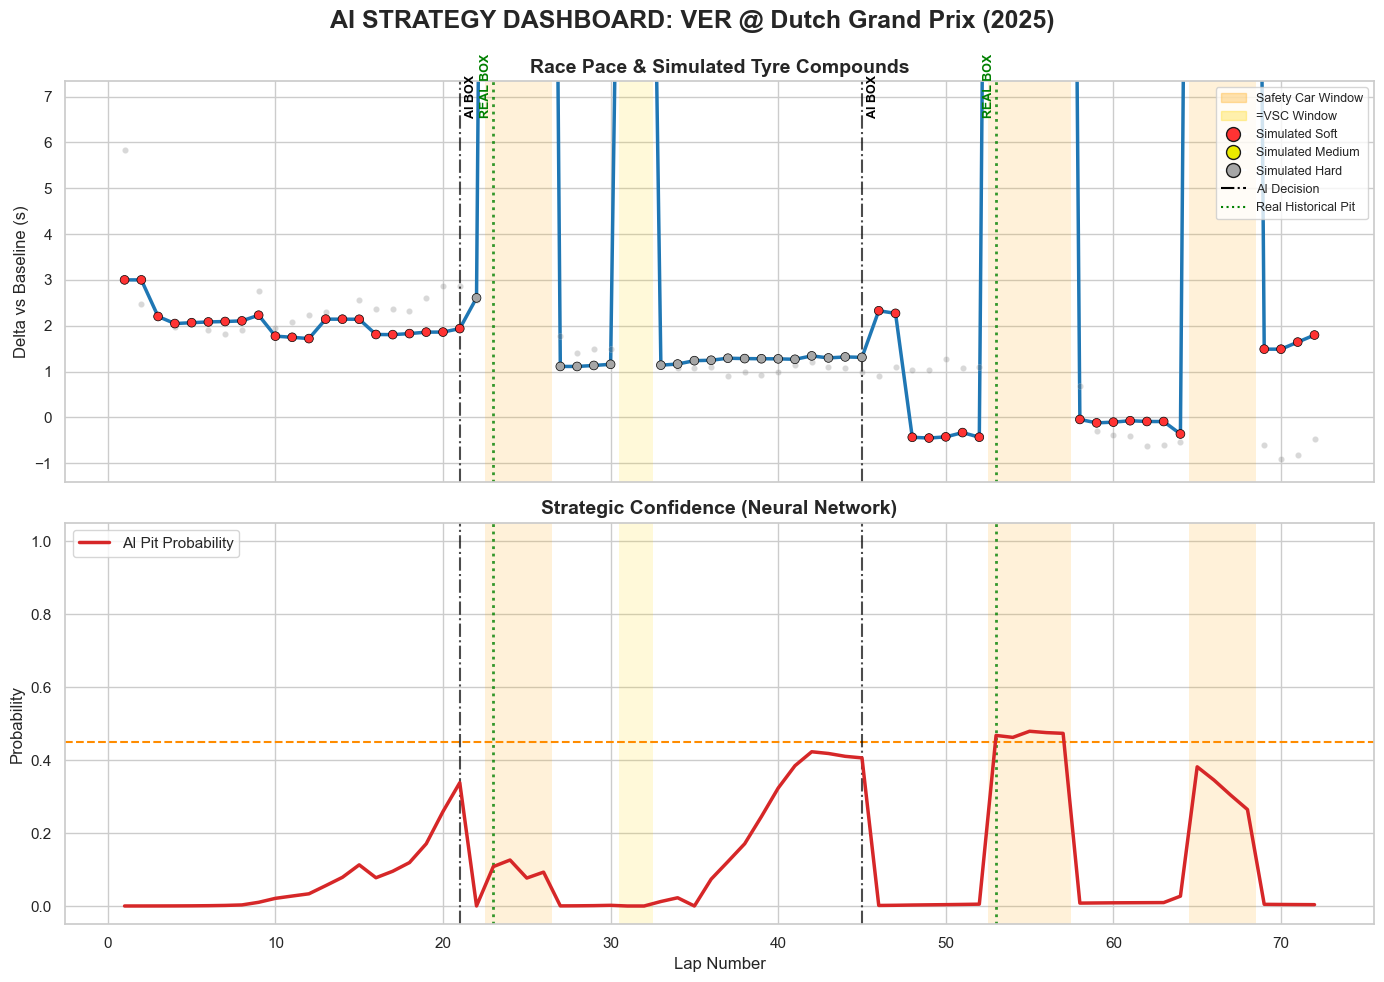

⏳ Calcolando strategia per: Emilia Romagna Grand Prix...

🟢 INIZIO GARA: Emilia Romagna Grand Prix (2025) | Pilota: VER | Mescola Partenza: MEDIUM
------------------------------------------------------------

[LAP 22] 📻 TEAM RADIO
   🧠 Alert Rete Neurale: Probabilità Pit Stop al 0.46
   📊 Valutazione IA: STAY_OUT: 121.2s | BOX_SOFT: 133.0s | BOX_HARD: 122.1s
   👉 Decisione Presa: STAY OUT

[LAP 23] 📻 TEAM RADIO
   🧠 Alert Rete Neurale: Probabilità Pit Stop al 0.48
   📊 Valutazione IA: STAY_OUT: 117.8s | BOX_SOFT: 130.7s | BOX_HARD: 118.7s
   👉 Decisione Presa: STAY OUT

[LAP 24] 📻 TEAM RADIO
   🧠 Alert Rete Neurale: Probabilità Pit Stop al 0.50
   📊 Valutazione IA: STAY_OUT: 114.3s | BOX_SOFT: 127.9s | BOX_HARD: 115.2s
   👉 Decisione Presa: STAY OUT

[LAP 25] 📻 TEAM RADIO
   🧠 Alert Rete Neurale: Probabilità Pit Stop al 0.53
   📊 Valutazione IA: STAY_OUT: 110.7s | BOX_SOFT: 125.9s | BOX_HARD: 111.6s
   👉 Decisione Presa: STAY OUT

[LAP 26] 📻 TEAM RADIO
   🧠 Alert Rete Neurale: Probabil

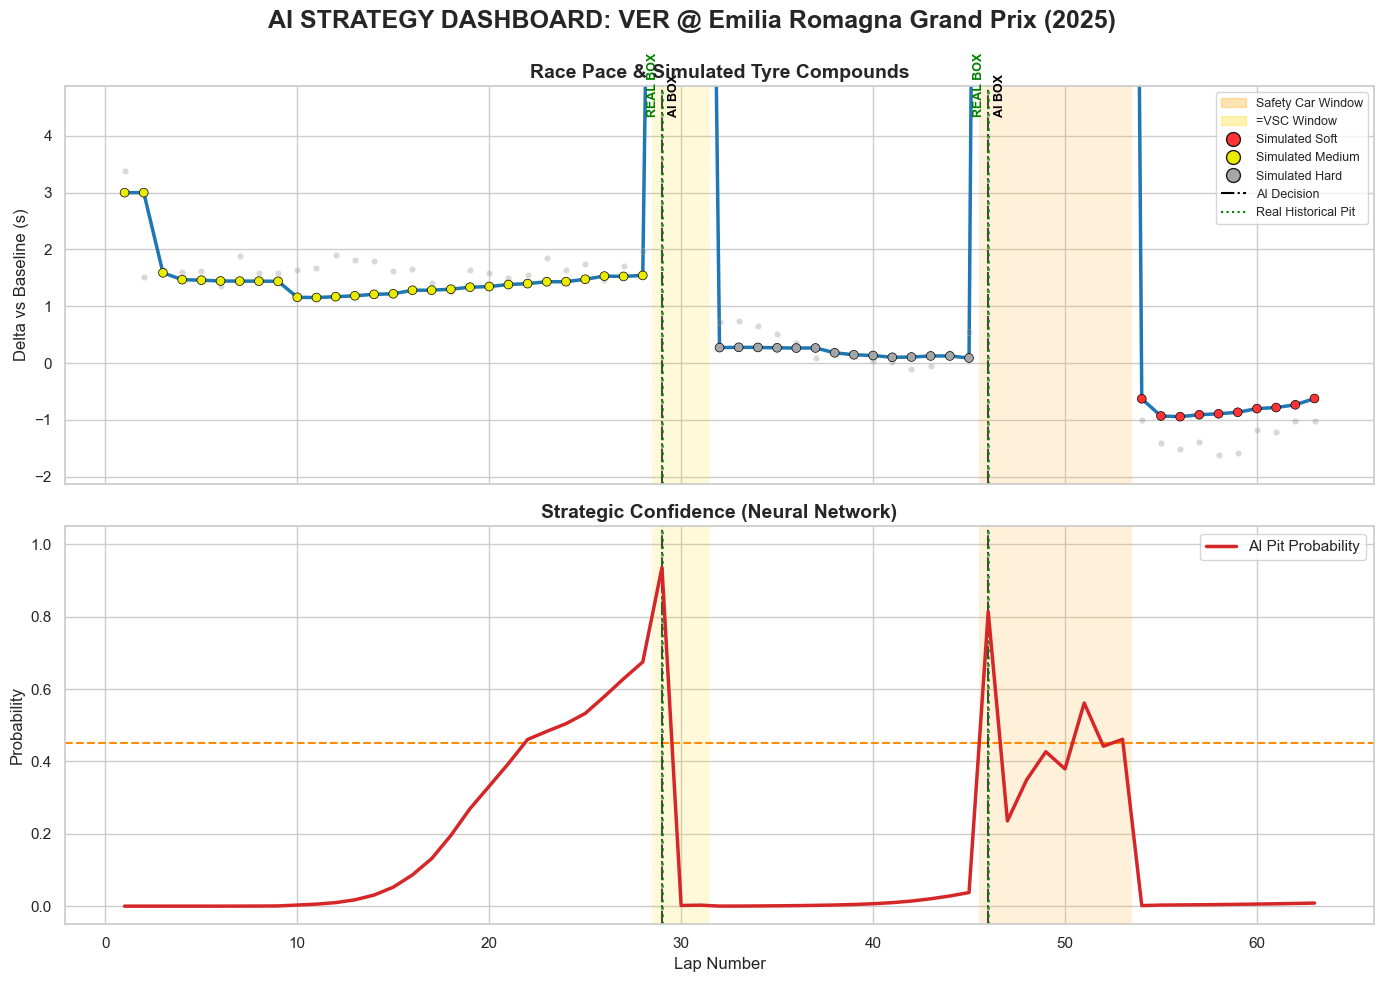


🏆 CAMPIONATO SIMULATO CON SUCCESSO!


In [67]:
# full races XGB V6
import matplotlib.pyplot as plt

# ==========================================
# ⚙️ PANNELLO DI CONTROLLO
# ==========================================
TARGET_DRIVER = 'VER'
TARGET_YEAR = 2025
TARGET_DF = df_race
# ==========================================

# ==========================================
# ⚙️ IMPOSTAZIONI INTERVALLO GARE
# ==========================================
START_IDX = 3  # Indice di partenza
END_IDX = 5    # Indice di fine (escluso)
# ==========================================

# 1. Trova tutte le gare completate
df_target = TARGET_DF[(TARGET_DF['Year'] == TARGET_YEAR) & (TARGET_DF[f'Driver_{TARGET_DRIVER}'] == 1)]
completed_gps = []

for gp_name, gp_data in df_target.groupby('GP'):
    if gp_data['RaceProgress'].max() >= 0.99:
        completed_gps.append(gp_name)

# 2. Taglia la lista tenendo solo l'intervallo scelto
completed_gps = completed_gps[START_IDX:END_IDX]

print(f"🏁 Trovate le gare nell'intervallo scelto ({START_IDX} - {END_IDX}):")
print(completed_gps)
print(f"🏁 INIZIO TEST GLOBALE SU {len(completed_gps)} GRAN PREMI...\n")

simulations = []

# 3. Esegui la simulazione gara per gara
for gp in completed_gps:
    print(f"⏳ Calcolando strategia per: {gp}...")
    
    sim_df = run_stochastic_dynamic_strategy_test_year(
        TARGET_DF, gp, TARGET_DRIVER, TARGET_YEAR, 
        nn_model, best_xgb_model, xgb_features, nn_features, sc_prob_matrix
    )
    
    if sim_df is not None:
        print(f"✅ Gara {gp} completata. Generazione grafico e resoconto...")
        
        # =========================================================
        # 📝 STAMPA DEL RESOCONTO STRATEGICO (Solo Pit Stops)
        # =========================================================
        pit_stops = sim_df[sim_df['Action'].str.contains("BOX")]
        
        print("\n" + "="*60)
        print(f"📋 RESOCONTO STRATEGICO UFFICIALE: {gp.upper()}")
        print("="*60)
        
        if pit_stops.empty:
            print(" ❌ Nessun Pit Stop effettuato (Strategia a 0 soste o gara interrotta).")
        else:
            for _, row in pit_stops.iterrows():
                lap = row['Lap']
                action = row['Action']
                prob = row['AI_Pit_Prob']
                sc_risk = row.get('SC_Risk_Prob', 0.0)
                
                # Prende i tempi gestendo eventuali valori nulli
                t_stay = row.get('Time_If_Stay_Out', 0)
                t_soft = row.get('Time_If_Box_Soft', 0)
                t_med  = row.get('Time_If_Box_Medium', 0)
                t_hard = row.get('Time_If_Box_Hard', 0)
                
                print(f"▶ GIRO {lap} | Decisione: {action}")
                print(f"  ├ Gomma smontata: {row['Sim_Compound']} (Età: {row['Sim_TyreAge_StartOfLap']} giri)")
                print(f"  ├ Alert Rete Neurale: {prob:.2f} | Rischio Statistico SC: {sc_risk:.1%}")
                print(f"  └ Proiezioni IA (Expected Value a fine gara):")
                print(f"      STAY OUT : {t_stay:.1f}s")
                print(f"      BOX SOFT : {t_soft:.1f}s")
                print(f"      BOX MED  : {t_med:.1f}s")
                print(f"      BOX HARD : {t_hard:.1f}s")
                print("-" * 60)
        print("\n")
        # =========================================================

        real_df = TARGET_DF[(TARGET_DF['GP'] == gp) & 
                            (TARGET_DF[f'Driver_{TARGET_DRIVER}'] == 1) & 
                            (TARGET_DF['Year'] == TARGET_YEAR)]
        
        plot_simulation_vs_reality_v2(
            sim_df=sim_df, 
            real_df=real_df, 
            driver_code=TARGET_DRIVER, 
            gp_name=gp, 
            year=TARGET_YEAR
        )
        plt.show() 

    simulations.append(sim_df)
    
print("\n🏆 CAMPIONATO SIMULATO CON SUCCESSO!")

🏁 Trovate le gare nell'intervallo scelto (3 - 5):
['Dutch Grand Prix', 'Emilia Romagna Grand Prix']
🏁 INIZIO TEST GLOBALE SU 2 GRAN PREMI...

⏳ Calcolando strategia per: Dutch Grand Prix...

🟢 INIZIO GARA: Dutch Grand Prix (2025) | Pilota: VER | Mescola Partenza: SOFT
------------------------------------------------------------

[LAP 16] 📻 TEAM RADIO
   📊 Valutazione IA: STAY_OUT: 214.9s | BOX_MEDIUM: 232.9s | BOX_HARD: 211.0s
   👉 Decisione Presa: BOX (STRATEGY)

[LAP 23] 📻 TEAM RADIO
   🟡 SAFETY CAR / VSC DEPLOYED!
   📊 Valutazione IA: STAY_OUT: 268.9s | BOX_SOFT: 277.7s | BOX_MEDIUM: 286.7s
   👉 Decisione Presa: STAY OUT

[LAP 24] 📻 TEAM RADIO
   🧠 Alert Rete Neurale: Probabilità Pit Stop al 0.43
   📊 Valutazione IA: STAY_OUT: 266.1s | BOX_SOFT: 276.3s | BOX_MEDIUM: 285.3s
   👉 Decisione Presa: STAY OUT

[LAP 31] 📻 TEAM RADIO
   🟡 SAFETY CAR / VSC DEPLOYED!
   🧠 Alert Rete Neurale: Probabilità Pit Stop al 0.49
   📊 Valutazione IA: STAY_OUT: 245.4s | BOX_SOFT: 250.9s | BOX_MEDIUM: 26

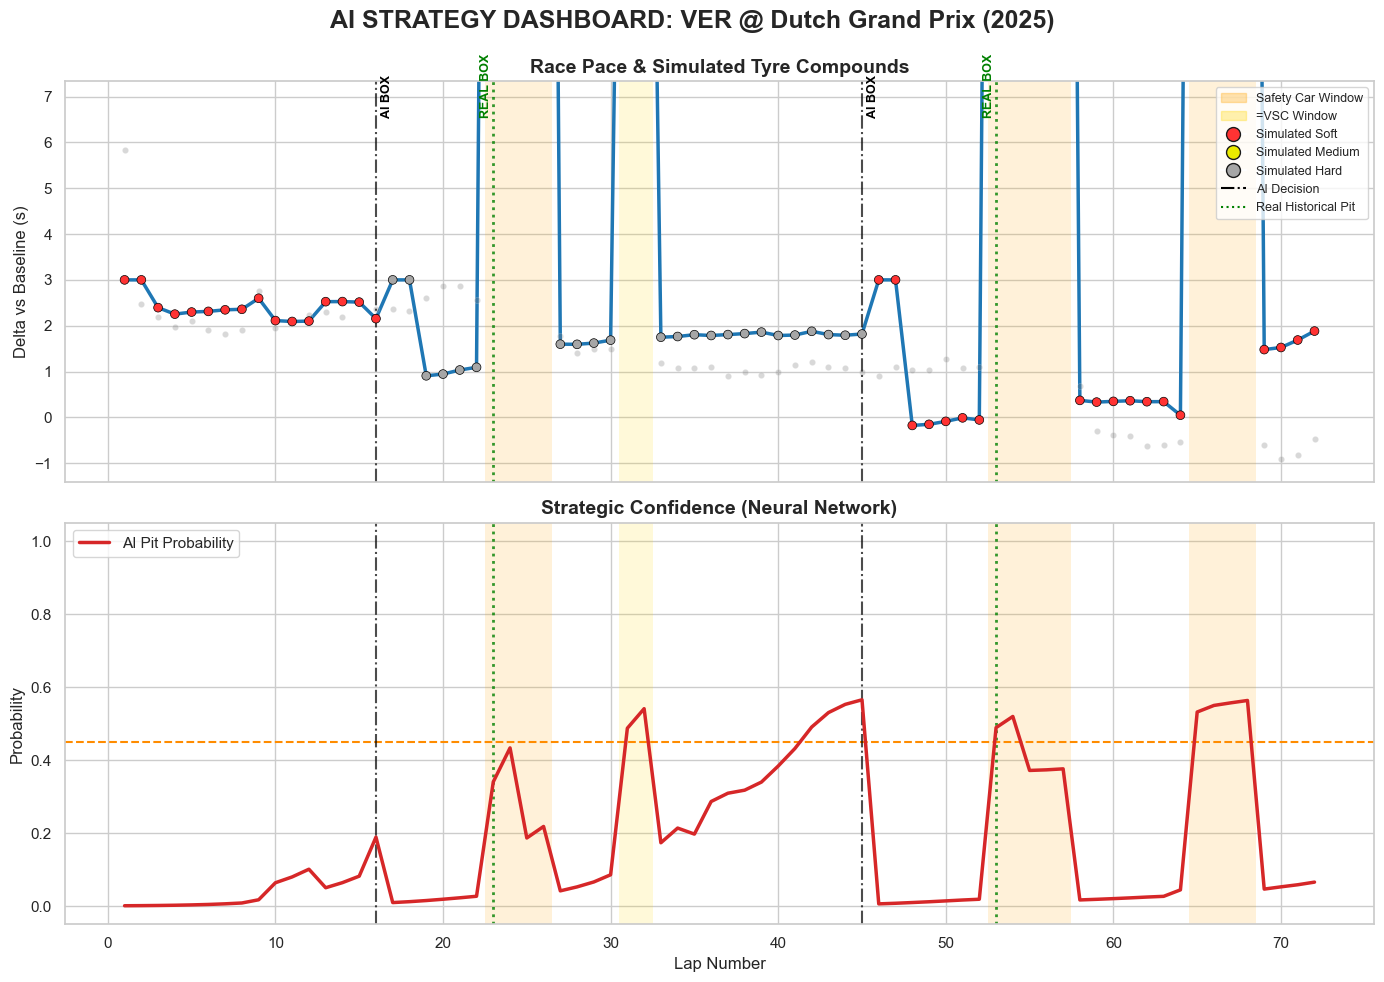

⏳ Calcolando strategia per: Emilia Romagna Grand Prix...

🟢 INIZIO GARA: Emilia Romagna Grand Prix (2025) | Pilota: VER | Mescola Partenza: MEDIUM
------------------------------------------------------------

[LAP 20] 📻 TEAM RADIO
   🧠 Alert Rete Neurale: Probabilità Pit Stop al 0.44
   📊 Valutazione IA: STAY_OUT: 122.2s | BOX_SOFT: 134.0s | BOX_HARD: 133.9s
   👉 Decisione Presa: STAY OUT

[LAP 21] 📻 TEAM RADIO
   🧠 Alert Rete Neurale: Probabilità Pit Stop al 0.51
   📊 Valutazione IA: STAY_OUT: 119.5s | BOX_SOFT: 131.7s | BOX_HARD: 135.0s
   👉 Decisione Presa: STAY OUT

[LAP 22] 📻 TEAM RADIO
   🧠 Alert Rete Neurale: Probabilità Pit Stop al 0.57
   📊 Valutazione IA: STAY_OUT: 116.3s | BOX_SOFT: 129.2s | BOX_HARD: 117.2s
   👉 Decisione Presa: STAY OUT

[LAP 23] 📻 TEAM RADIO
   🧠 Alert Rete Neurale: Probabilità Pit Stop al 0.60
   📊 Valutazione IA: STAY_OUT: 113.1s | BOX_SOFT: 127.1s | BOX_HARD: 114.0s
   👉 Decisione Presa: STAY OUT

[LAP 24] 📻 TEAM RADIO
   🧠 Alert Rete Neurale: Probabil

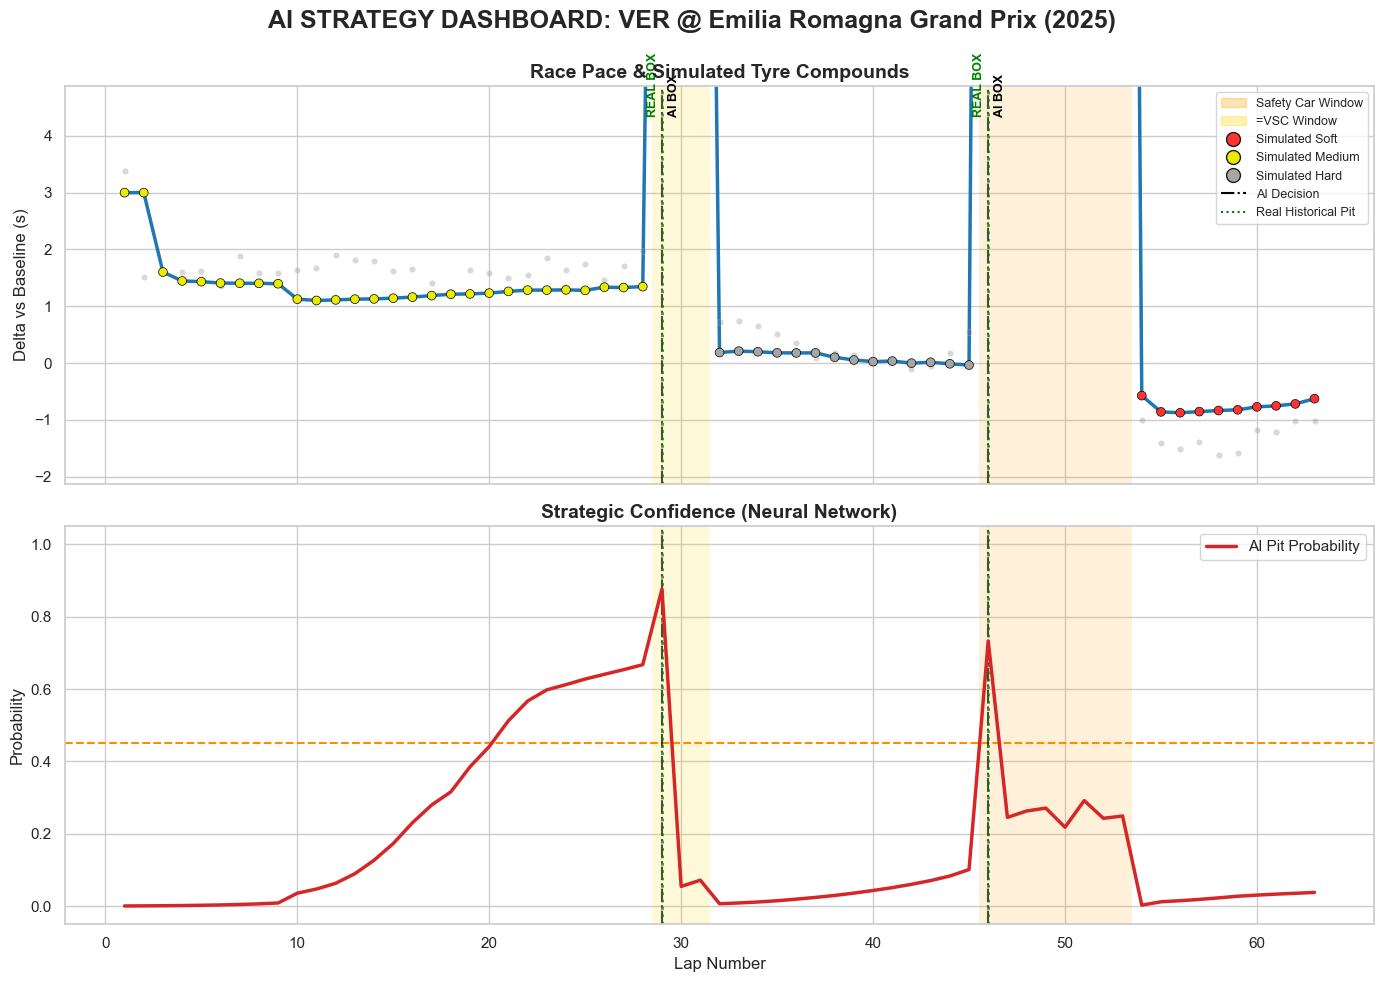


🏆 CAMPIONATO SIMULATO CON SUCCESSO!


In [15]:
# full races
import matplotlib.pyplot as plt

# ==========================================
# ⚙️ PANNELLO DI CONTROLLO
# ==========================================
TARGET_DRIVER = 'VER'
TARGET_YEAR = 2025
TARGET_DF = df_race
# ==========================================

# ==========================================
# ⚙️ IMPOSTAZIONI INTERVALLO GARE
# ==========================================
START_IDX = 3  # Indice di partenza
END_IDX = 5    # Indice di fine (escluso)
# ==========================================

# 1. Trova tutte le gare completate
df_target = TARGET_DF[(TARGET_DF['Year'] == TARGET_YEAR) & (TARGET_DF[f'Driver_{TARGET_DRIVER}'] == 1)]
completed_gps = []

for gp_name, gp_data in df_target.groupby('GP'):
    if gp_data['RaceProgress'].max() >= 0.99:
        completed_gps.append(gp_name)

# 2. Taglia la lista tenendo solo l'intervallo scelto
completed_gps = completed_gps[START_IDX:END_IDX]

print(f"🏁 Trovate le gare nell'intervallo scelto ({START_IDX} - {END_IDX}):")
print(completed_gps)
print(f"🏁 INIZIO TEST GLOBALE SU {len(completed_gps)} GRAN PREMI...\n")

simulations = []

# 3. Esegui la simulazione gara per gara
for gp in completed_gps:
    print(f"⏳ Calcolando strategia per: {gp}...")
    
    sim_df = run_stochastic_dynamic_strategy_test(
        TARGET_DF, gp, TARGET_DRIVER, TARGET_YEAR, 
        nn_model, best_xgb_model, xgb_features, nn_features, sc_prob_matrix
    )
    
    if sim_df is not None:
        print(f"✅ Gara {gp} completata. Generazione grafico e resoconto...")
        
        # =========================================================
        # 📝 STAMPA DEL RESOCONTO STRATEGICO (Solo Pit Stops)
        # =========================================================
        pit_stops = sim_df[sim_df['Action'].str.contains("BOX")]
        
        print("\n" + "="*60)
        print(f"📋 RESOCONTO STRATEGICO UFFICIALE: {gp.upper()}")
        print("="*60)
        
        if pit_stops.empty:
            print(" ❌ Nessun Pit Stop effettuato (Strategia a 0 soste o gara interrotta).")
        else:
            for _, row in pit_stops.iterrows():
                lap = row['Lap']
                action = row['Action']
                prob = row['AI_Pit_Prob']
                sc_risk = row.get('SC_Risk_Prob', 0.0)
                
                # Prende i tempi gestendo eventuali valori nulli
                t_stay = row.get('Time_If_Stay_Out', 0)
                t_soft = row.get('Time_If_Box_Soft', 0)
                t_med  = row.get('Time_If_Box_Medium', 0)
                t_hard = row.get('Time_If_Box_Hard', 0)
                
                print(f"▶ GIRO {lap} | Decisione: {action}")
                print(f"  ├ Gomma smontata: {row['Sim_Compound']} (Età: {row['Sim_TyreAge_StartOfLap']} giri)")
                print(f"  ├ Alert Rete Neurale: {prob:.2f} | Rischio Statistico SC: {sc_risk:.1%}")
                print(f"  └ Proiezioni IA (Expected Value a fine gara):")
                print(f"      STAY OUT : {t_stay:.1f}s")
                print(f"      BOX SOFT : {t_soft:.1f}s")
                print(f"      BOX MED  : {t_med:.1f}s")
                print(f"      BOX HARD : {t_hard:.1f}s")
                print("-" * 60)
        print("\n")
        # =========================================================

        real_df = TARGET_DF[(TARGET_DF['GP'] == gp) & 
                            (TARGET_DF[f'Driver_{TARGET_DRIVER}'] == 1) & 
                            (TARGET_DF['Year'] == TARGET_YEAR)]
        
        plot_simulation_vs_reality_v2(
            sim_df=sim_df, 
            real_df=real_df, 
            driver_code=TARGET_DRIVER, 
            gp_name=gp, 
            year=TARGET_YEAR
        )
        plt.show() 

    simulations.append(sim_df)
    
print("\n🏆 CAMPIONATO SIMULATO CON SUCCESSO!")

🏁 Trovate le gare nell'intervallo scelto (3 - 5):
['Dutch Grand Prix', 'Emilia Romagna Grand Prix']
🏁 INIZIO TEST GLOBALE SU 2 GRAN PREMI...

⏳ Calcolando strategia per: Dutch Grand Prix...

🟢 INIZIO GARA: Dutch Grand Prix (2025) | Pilota: PIA | Mescola Partenza: MEDIUM
------------------------------------------------------------

[LAP 8] 📻 TEAM RADIO
   📊 Valutazione IA: STAY_OUT: 229.3s | BOX_SOFT: 229.7s | BOX_HARD: 228.2s
   👉 Decisione Presa: BOX (STRATEGY)

[LAP 23] 📻 TEAM RADIO
   🟡 SAFETY CAR / VSC DEPLOYED!
   🚨 NN VETO ACTIVATED (Prob: 0.75) - STAY OUT scartato per difesa!
   📊 Valutazione IA: BOX_SOFT: 257.1s | BOX_MEDIUM: 281.4s
   👉 Decisione Presa: BOX (SAFETY CAR)

[LAP 31] 📻 TEAM RADIO
   🟡 SAFETY CAR / VSC DEPLOYED!
   📊 Valutazione IA: STAY_OUT: 222.7s | BOX_MEDIUM: 244.2s | BOX_HARD: 246.9s
   👉 Decisione Presa: STAY OUT

[LAP 48] 📻 TEAM RADIO
   📊 Valutazione IA: STAY_OUT: 91.2s | BOX_MEDIUM: 91.2s | BOX_HARD: 99.3s
   👉 Decisione Presa: BOX (STRATEGY)

[LAP 53] 📻 T

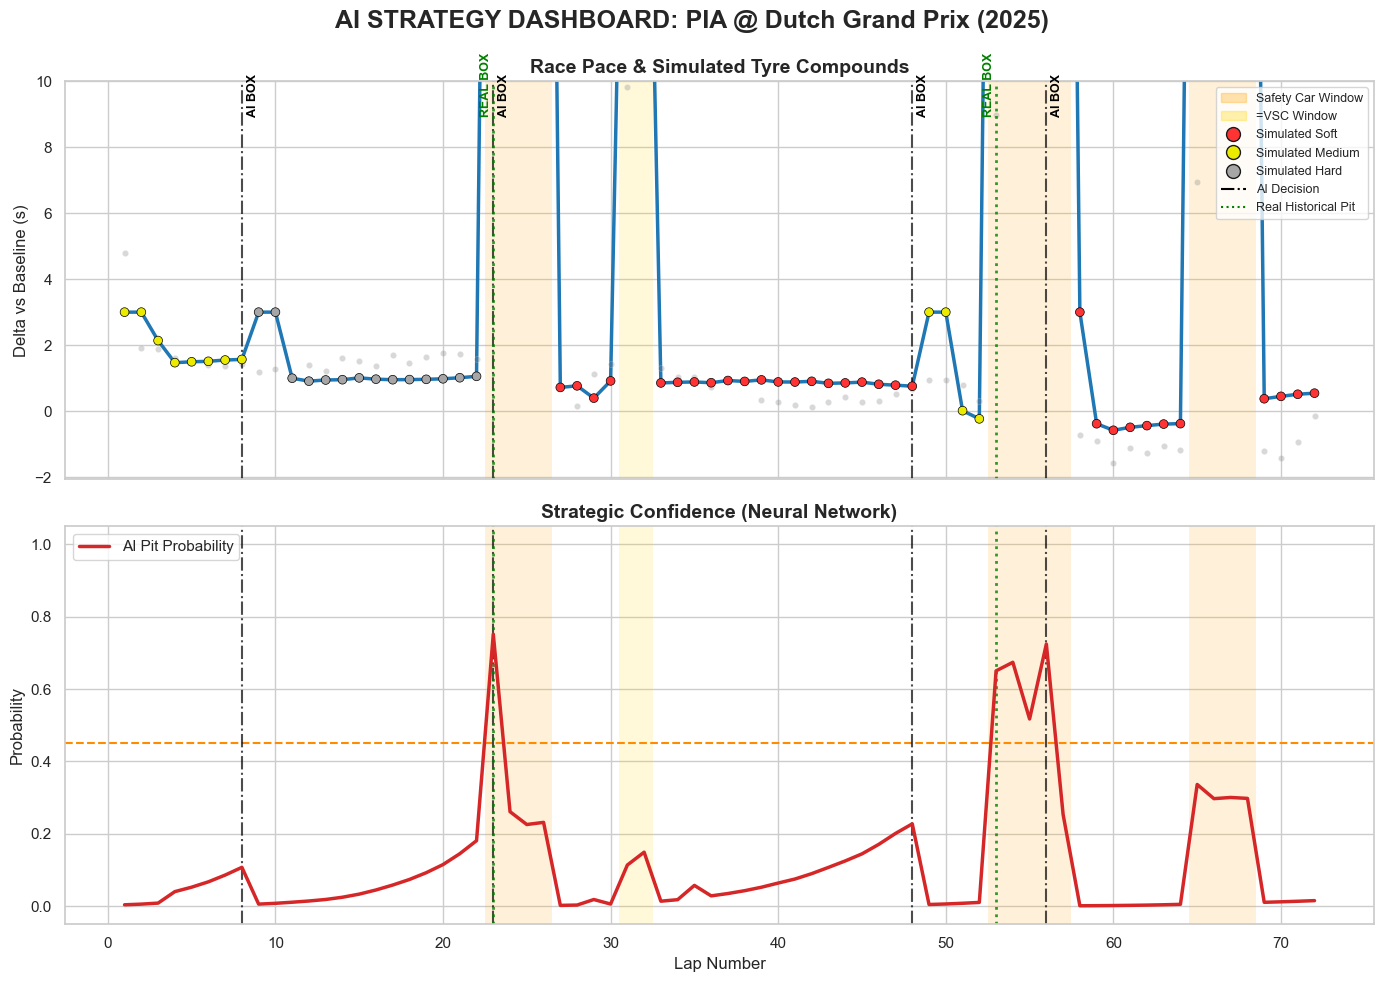

⏳ Calcolando strategia per: Emilia Romagna Grand Prix...

🟢 INIZIO GARA: Emilia Romagna Grand Prix (2025) | Pilota: PIA | Mescola Partenza: MEDIUM
------------------------------------------------------------

[LAP 14] 📻 TEAM RADIO
   🧠 Alert Rete Neurale: Probabilità Pit Stop al 0.58
   📊 Valutazione IA: STAY_OUT: 159.4s | BOX_SOFT: 161.3s | BOX_HARD: 184.8s
   👉 Decisione Presa: STAY OUT

[LAP 15] 📻 TEAM RADIO
   🧠 Alert Rete Neurale: Probabilità Pit Stop al 0.59
   📊 Valutazione IA: STAY_OUT: 155.8s | BOX_SOFT: 158.2s | BOX_HARD: 156.6s
   👉 Decisione Presa: STAY OUT

[LAP 16] 📻 TEAM RADIO
   🧠 Alert Rete Neurale: Probabilità Pit Stop al 0.47
   📊 Valutazione IA: STAY_OUT: 153.3s | BOX_SOFT: 155.2s | BOX_HARD: 153.0s
   👉 Decisione Presa: BOX (STRATEGY)

[LAP 29] 📻 TEAM RADIO
   🟡 SAFETY CAR / VSC DEPLOYED!
   🧠 Alert Rete Neurale: Probabilità Pit Stop al 0.45
   📊 Valutazione IA: STAY_OUT: 193.1s | BOX_SOFT: 206.5s | BOX_MEDIUM: 183.4s
   👉 Decisione Presa: BOX (SAFETY CAR)

[LAP 46

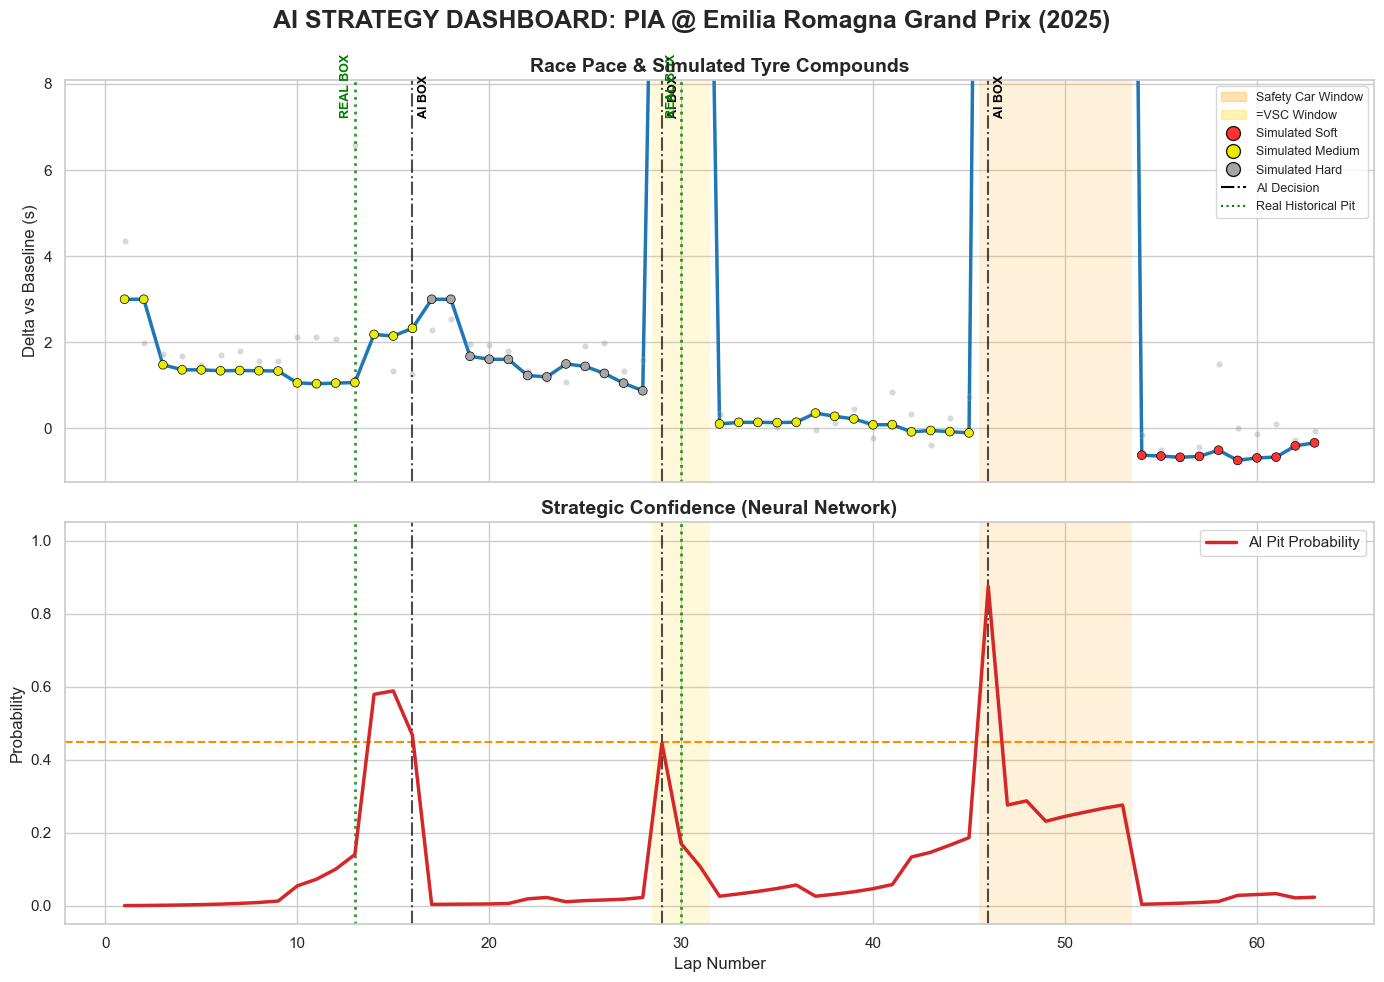


🏆 CAMPIONATO SIMULATO CON SUCCESSO!


In [16]:
# full races
import matplotlib.pyplot as plt

# ==========================================
# ⚙️ PANNELLO DI CONTROLLO
# ==========================================
TARGET_DRIVER = 'PIA'
TARGET_YEAR = 2025
TARGET_DF = df_race
# ==========================================

# ==========================================
# ⚙️ IMPOSTAZIONI INTERVALLO GARE
# ==========================================
START_IDX = 3  # Indice di partenza
END_IDX = 5    # Indice di fine (escluso)
# ==========================================

# 1. Trova tutte le gare completate
df_target = TARGET_DF[(TARGET_DF['Year'] == TARGET_YEAR) & (TARGET_DF[f'Driver_{TARGET_DRIVER}'] == 1)]
completed_gps = []

for gp_name, gp_data in df_target.groupby('GP'):
    if gp_data['RaceProgress'].max() >= 0.99:
        completed_gps.append(gp_name)

# 2. Taglia la lista tenendo solo l'intervallo scelto
completed_gps = completed_gps[START_IDX:END_IDX]

print(f"🏁 Trovate le gare nell'intervallo scelto ({START_IDX} - {END_IDX}):")
print(completed_gps)
print(f"🏁 INIZIO TEST GLOBALE SU {len(completed_gps)} GRAN PREMI...\n")

simulations = []

# 3. Esegui la simulazione gara per gara
for gp in completed_gps:
    print(f"⏳ Calcolando strategia per: {gp}...")
    
    sim_df = run_stochastic_dynamic_strategy_test(
        TARGET_DF, gp, TARGET_DRIVER, TARGET_YEAR, 
        nn_model, best_xgb_model, xgb_features, nn_features, sc_prob_matrix
    )
    
    if sim_df is not None:
        print(f"✅ Gara {gp} completata. Generazione grafico e resoconto...")
        
        # =========================================================
        # 📝 STAMPA DEL RESOCONTO STRATEGICO (Solo Pit Stops)
        # =========================================================
        pit_stops = sim_df[sim_df['Action'].str.contains("BOX")]
        
        print("\n" + "="*60)
        print(f"📋 RESOCONTO STRATEGICO UFFICIALE: {gp.upper()}")
        print("="*60)
        
        if pit_stops.empty:
            print(" ❌ Nessun Pit Stop effettuato (Strategia a 0 soste o gara interrotta).")
        else:
            for _, row in pit_stops.iterrows():
                lap = row['Lap']
                action = row['Action']
                prob = row['AI_Pit_Prob']
                sc_risk = row.get('SC_Risk_Prob', 0.0)
                
                # Prende i tempi gestendo eventuali valori nulli
                t_stay = row.get('Time_If_Stay_Out', 0)
                t_soft = row.get('Time_If_Box_Soft', 0)
                t_med  = row.get('Time_If_Box_Medium', 0)
                t_hard = row.get('Time_If_Box_Hard', 0)
                
                print(f"▶ GIRO {lap} | Decisione: {action}")
                print(f"  ├ Gomma smontata: {row['Sim_Compound']} (Età: {row['Sim_TyreAge_StartOfLap']} giri)")
                print(f"  ├ Alert Rete Neurale: {prob:.2f} | Rischio Statistico SC: {sc_risk:.1%}")
                print(f"  └ Proiezioni IA (Expected Value a fine gara):")
                print(f"      STAY OUT : {t_stay:.1f}s")
                print(f"      BOX SOFT : {t_soft:.1f}s")
                print(f"      BOX MED  : {t_med:.1f}s")
                print(f"      BOX HARD : {t_hard:.1f}s")
                print("-" * 60)
        print("\n")
        # =========================================================

        real_df = TARGET_DF[(TARGET_DF['GP'] == gp) & 
                            (TARGET_DF[f'Driver_{TARGET_DRIVER}'] == 1) & 
                            (TARGET_DF['Year'] == TARGET_YEAR)]
        
        plot_simulation_vs_reality_v2(
            sim_df=sim_df, 
            real_df=real_df, 
            driver_code=TARGET_DRIVER, 
            gp_name=gp, 
            year=TARGET_YEAR
        )
        plt.show() 

    simulations.append(sim_df)
    
print("\n🏆 CAMPIONATO SIMULATO CON SUCCESSO!")

In [4]:
df_race.query("GP == 'Emilia Romagna Grand Prix' and Year == 2025 and Driver_PIA == 1")

,LapNumber,Team,Position,InPits,TrackTemp,Year,GP,RaceProgress,TyreLifeProgress,CarClose,...,Driver_RAI,Driver_RIC,Driver_RUS,Driver_SAI,Driver_SAR,Driver_STR,Driver_TSU,Driver_VER,Driver_VET,Driver_ZHO
97026,1.0,McLaren,2.0,0,42.664,2025,Emilia Romagna Grand Prix,0.015873,0.029412,1,...,0,0,0,0,0,0,0,0,0,0
97046,2.0,McLaren,2.0,0,42.664,2025,Emilia Romagna Grand Prix,0.031746,0.058824,1,...,0,0,0,0,0,0,0,0,0,0
97066,3.0,McLaren,2.0,0,42.664,2025,Emilia Romagna Grand Prix,0.047619,0.088235,1,...,0,0,0,0,0,0,0,0,0,0
97086,4.0,McLaren,2.0,0,42.664,2025,Emilia Romagna Grand Prix,0.063492,0.117647,1,...,0,0,0,0,0,0,0,0,0,0
97106,5.0,McLaren,2.0,0,42.664,2025,Emilia Romagna Grand Prix,0.079365,0.147059,1,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
98142,59.0,McLaren,3.0,0,42.664,2025,Emilia Romagna Grand Prix,0.936508,0.828571,0,...,0,0,0,0,0,0,0,0,0,0
98160,60.0,McLaren,3.0,0,42.664,2025,Emilia Romagna Grand Prix,0.952381,0.857143,0,...,0,0,0,0,0,0,0,0,0,0
98178,61.0,McLaren,3.0,0,42.664,2025,Emilia Romagna Grand Prix,0.968254,0.885714,0,...,0,0,0,0,0,0,0,0,0,0
98196,62.0,McLaren,3.0,0,42.664,2025,Emilia Romagna Grand Prix,0.984127,0.914286,1,...,0,0,0,0,0,0,0,0,0,0


# CORRELATION  

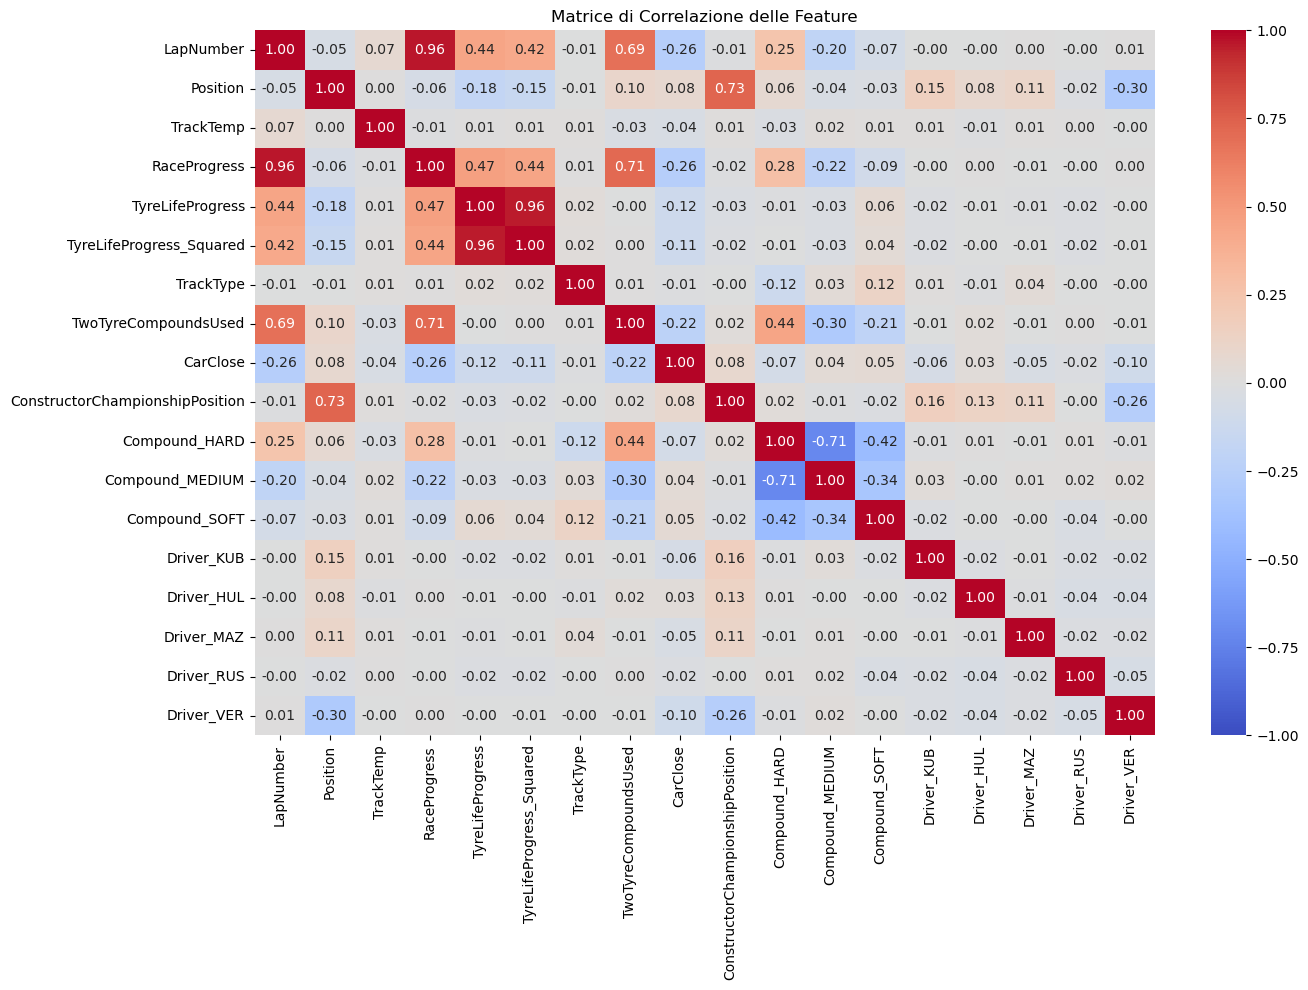

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calcola la matrice di correlazione
corr_matrix = df_race[xgb_cols_to_keep + ['Driver_KUB', 'Driver_HUL', 'Driver_MAZ', 'Driver_RUS', 'Driver_VER']].corr()

# Heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, 
            annot=True, 
            fmt='.2f', 
            cmap='coolwarm',
            center=0,
            vmin=-1, vmax=1)
plt.title('Matrice di Correlazione delle Feature')
plt.tight_layout()
plt.show()

In [ ]:
from scipy import stats
corr, pvalue = stats.pointbiserialr(df_race['ConstructorChampionshipPosition'], df_race['Driver_KUB'])
print(f'Correlazione: {corr:.3f}, p-value: {pvalue:.4f}')

Correlazione: 0.159, p-value: 0.0000


: 

# Analisi XGB


In [5]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

# Predizioni sul test set
y_pred = best_xgb_model.predict(X_test_xgb_2)

# Calcolo metriche
mae = mean_absolute_error(y_test_xgb_2, y_pred)
rmse = root_mean_squared_error(y_test_xgb_2, y_pred)
r2 = r2_score(y_test_xgb_2, y_pred)

print("📊 Metriche sul Test Set 2025:")
print(f"   MAE:  {mae:.3f} secondi")
print(f"   RMSE: {rmse:.3f} secondi")
print(f"   R²:   {r2:.3f}")

📊 Metriche sul Test Set 2025:
   MAE:  0.643 secondi
   RMSE: 0.906 secondi
   R²:   0.526


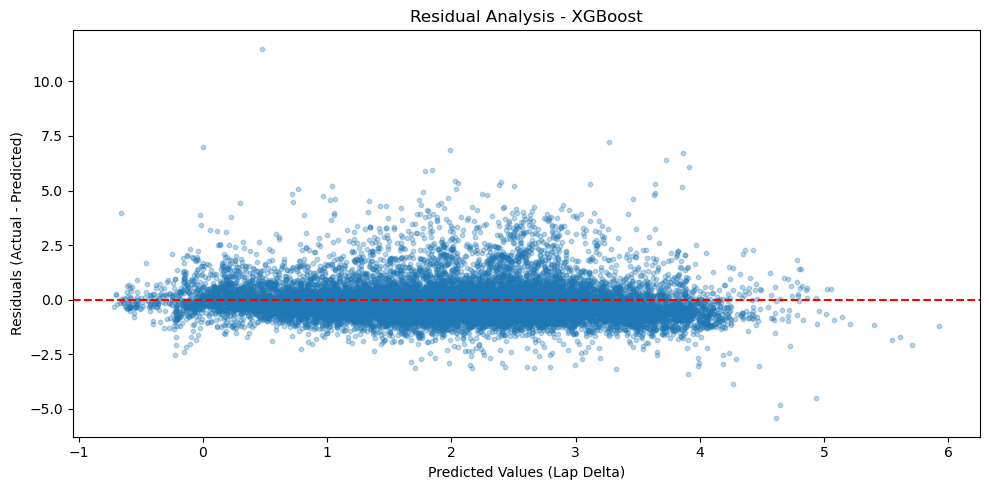

In [6]:
import matplotlib.pyplot as plt
import numpy as np

residuals = y_test_xgb_2 - y_pred

plt.figure(figsize=(10, 5))
plt.scatter(y_pred, residuals, alpha=0.3, s=10)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicted Values (Lap Delta)')
plt.ylabel('Residuals (Actual - Predicted)')
plt.title('Residual Analysis - XGBoost')
plt.tight_layout()
plt.show()

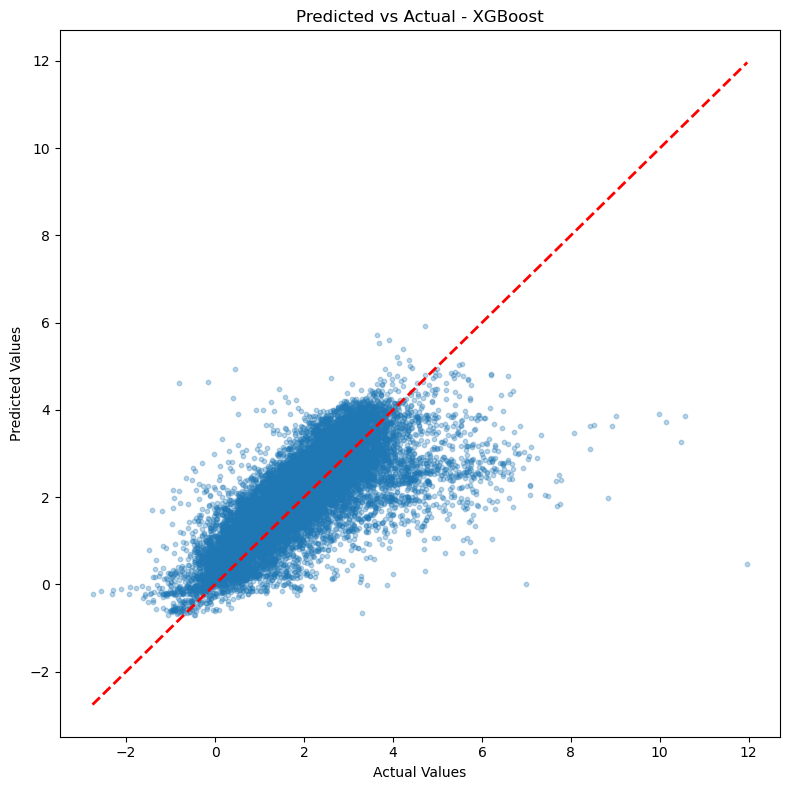

In [7]:
plt.figure(figsize=(8, 8))
plt.scatter(y_test_xgb_2, y_pred, alpha=0.3, s=10)
plt.plot([y_test_xgb_2.min(), y_test_xgb_2.max()], 
         [y_test_xgb_2.min(), y_test_xgb_2.max()], 
         'r--', linewidth=2)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Predicted vs Actual - XGBoost')
plt.tight_layout()
plt.show()

In [31]:
# Alternativa - usa X_test_xgb_2 che ha sicuramente gli stessi indici
mask_negativi = y_test_xgb_2 < -1
indici_negativi = y_test_xgb_2[mask_negativi].index

# Controlla quali colonne hai disponibili in X_test
print(X_test_xgb_2.loc[indici_negativi][['LapNumber', 
      'RaceProgress', 'TyreLifeProgress']].head(20))
print(f"\nTotale giri con delta < -1: {mask_negativi.sum()}")

       LapNumber  RaceProgress  TyreLifeProgress
95737       36.0      0.631579          0.129032
95738       36.0      0.631579          0.250000
95757       37.0      0.649123          0.161290
98050       54.0      0.857143          0.228571
98068       55.0      0.873016          0.257143
98086       56.0      0.888889          0.285714
98104       57.0      0.904762          0.314286
98109       57.0      0.904762          0.314286
98122       58.0      0.920635          0.342857
98140       59.0      0.936508          0.371429
98141       59.0      0.936508          0.400000
98158       60.0      0.952381          0.400000
98159       60.0      0.952381          0.428571
98176       61.0      0.968254          0.428571
98179       61.0      0.968254          0.428571
98194       62.0      0.984127          0.457143
98212       63.0      1.000000          0.485714
98213       63.0      1.000000          0.514286
98216       63.0      1.000000          0.457143
99597       74.0    

# Analisi NN

In [11]:
# ---------------------------------------------------------
# BUILD THE NEURAL NETWORK (M10 Architecture)
# ---------------------------------------------------------
# We use a Sequential model with Dense layers (Standard Feed-Forward Neural Network)
model = Sequential([
    # First Hidden Layer + Input Shape specification
    Dense(64, activation='relu', input_shape=(X_train_nn.shape[1],)),
    Dropout(0.2), # Randomly drops 20% of neurons to prevent overfitting
    
    # Second Hidden Layer
    Dense(32, activation='relu'),
    Dropout(0.2),
    
    # Third Hidden Layer
    Dense(16, activation='relu'),
    
    # Output Layer: 1 single neuron with Sigmoid activation
    # Sigmoid squashes the output between 0.0 and 1.0 (Probability of a Pit Stop)
    Dense(1, activation='sigmoid')
])

# ---------------------------------------------------------
# COMPILE THE MODEL
# ---------------------------------------------------------
# We use Binary Crossentropy for 1/0 classification.
# IMPORTANT: We add AUC, Precision, and Recall because 'accuracy' is misleading 
# when 97% of the laps are not pit stops!
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.AUC(name='auc'),
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)

# Display the network architecture
model.summary()

c:\Users\lucam\anaconda3\envs\myenv_310_f1\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,777 (14.75 KB)

 Trainable params: 3,777 (14.75 KB)

 Non-trainable params: 0 (0.00 B)

In [47]:
import numpy as np
from sklearn.utils import class_weight
from tensorflow.keras.callbacks import EarlyStopping

# ---------------------------------------------------------
# CALCULATE CLASS WEIGHTS (Addressing Imbalance)
# ---------------------------------------------------------
# Calculate weights to penalize the model heavily if it misses a pit stop (Class 1)
weights_array = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_nn),
    y=y_train_nn
)

# Convert to a dictionary for TensorFlow Keras
weights_dict = {0: weights_array[0], 1: weights_array[1]}
print(f"Class Weights applied: {weights_dict}")
# Class 1 (Pit Stop) gets a much higher weight than class 0!

# ---------------------------------------------------------
# EARLY STOPPING CALLBACK
# ---------------------------------------------------------
# Stop training if 'val_loss' doesn't improve for 15 epochs.
# restore_best_weights=True ensures we keep the most optimized version of the model.
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

# ---------------------------------------------------------
# TRAIN THE NEURAL NETWORK
# ---------------------------------------------------------
print("\n🟢 Starting Model Training (Grab a coffee, this might take a minute!)...")
history = model.fit(
    X_train_nn, y_train_nn,
    validation_data=(X_valid_nn, y_valid_nn),
    epochs=100,            # Maximum loops over the dataset
    batch_size=64,         # Number of rows processed at once
    class_weight=weights_dict, 
    callbacks=[early_stop],
    verbose=1              # Shows the progress bar
)

# ---------------------------------------------------------
# EVALUATE ON UNSEEN TEST DATA
# ---------------------------------------------------------
print("\n🏁 Evaluating the model on the unseen Test Set...")
test_results = model.evaluate(X_test_nn, y_test_nn, verbose=0)

# Extract metrics based on the compiled model
print("\n--- FINAL TEST RESULTS ---")
print(f"Loss:      {test_results[0]:.4f}")
print(f"Accuracy:  {test_results[1]:.4f}")
print(f"AUC:       {test_results[2]:.4f} (Higher is better, 0.5 is random guess)")
print(f"Precision: {test_results[3]:.4f} (When it predicts a pit stop, how often is it right?)")
print(f"Recall:    {test_results[4]:.4f} (Out of all real pit stops, how many did it catch?)")

Class Weights applied: {0: np.float64(0.5149078956378826), 1: np.float64(17.26963711529628)}

🟢 Starting Model Training (Grab a coffee, this might take a minute!)...
Epoch 1/100
1175/1175 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7634 - auc: 0.8732 - loss: 0.4437 - precision: 0.0935 - recall: 0.8245 - val_accuracy: 0.8195 - val_auc: 0.8757 - val_loss: 0.3662 - val_precision: 0.1124 - val_recall: 0.7592
Epoch 2/100
1175/1175 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7609 - auc: 0.8720 - loss: 0.4445 - precision: 0.0919 - recall: 0.8176 - val_accuracy: 0.8244 - val_auc: 0.8733 - val_loss: 0.3541 - val_precision: 0.1137 - val_recall: 0.7463
Epoch 3/100
1175/1175 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7620 - auc: 0.8729 - loss: 0.4447 - precision: 0.0924 - recall: 0.8186 - val_accuracy: 0.8223 - val_auc: 0.8750 - val_loss: 0.3749 - val_precision: 0.1157 - val_recall: 0.7739
Epoch 4/100
1175/1175 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7713 - auc: 0.8724 - loss: 0.4

In [48]:
import json

model_filename = 'f1_strategic_model_m10_v4.keras'
model.save(model_filename)
print(f"✅ Model successfully saved as '{model_filename}'!")

# Salva history
history_filename = 'f1_strategic_model_m10_v4_history.json'
with open(history_filename, 'w') as f:
    json.dump(history.history, f)
print(f"✅ History successfully saved as '{history_filename}'!")

✅ Model successfully saved as 'f1_strategic_model_m10_v4.keras'!
✅ History successfully saved as 'f1_strategic_model_m10_v4_history.json'!


In [ ]:
# import json

# with open('f1_strategic_model_m10_v4_history.json', 'r') as f:
#     history_data = json.load(f)

# # Usala direttamente per i grafici
# plt.plot(history_data['loss'], label='Train Loss')
# plt.plot(history_data['val_loss'], label='Validation Loss')

588/588 ━━━━━━━━━━━━━━━━━━━━ 0s 484us/step


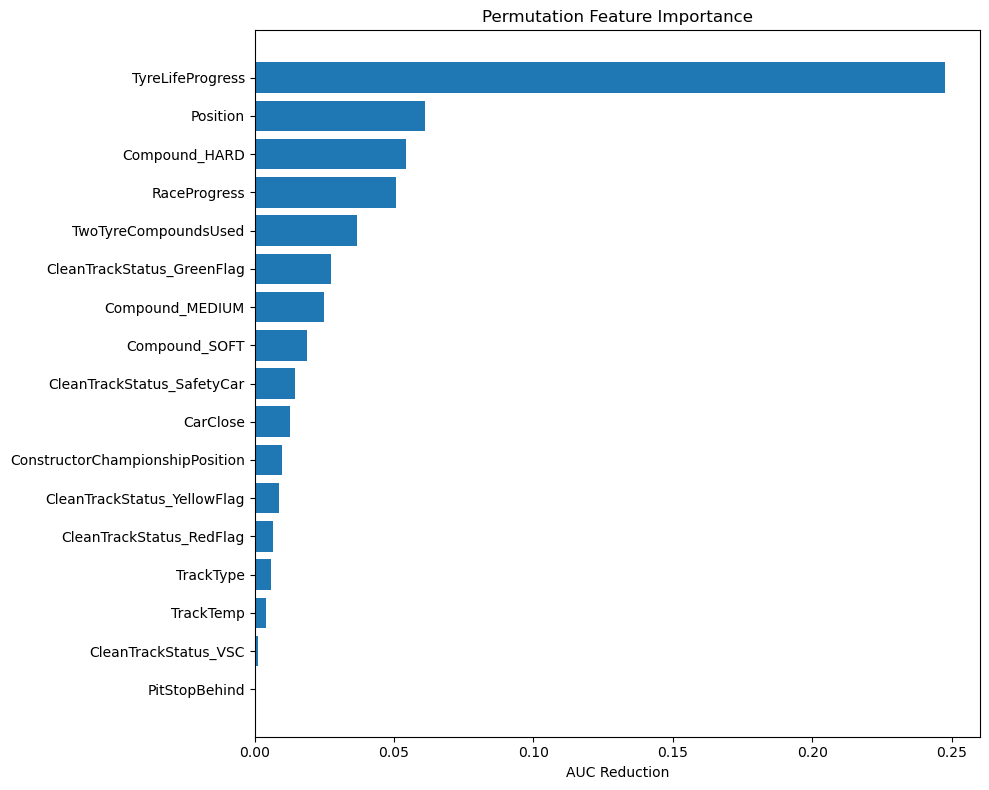

In [49]:
from sklearn.inspection import permutation_importance
from sklearn.base import BaseEstimator, ClassifierMixin
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score


# Permutation Importance con wrapper manuale
import numpy as np
baseline_auc = roc_auc_score(y_valid_nn, model.predict(X_valid_nn))

importances = []
for col in range(X_valid_nn.shape[1]):
    X_permuted = X_valid_nn.copy()
    X_permuted.iloc[:, col] = np.random.permutation(X_permuted.iloc[:, col])
    permuted_auc = roc_auc_score(y_valid_nn, model.predict(X_permuted, verbose=0))
    importances.append(baseline_auc - permuted_auc)

perm_df = pd.DataFrame({
    'Feature': nn_cols_to_keep,
    'Importance': importances
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(10, 8))
plt.barh(perm_df['Feature'], perm_df['Importance'])
plt.xlabel('AUC Reduction')
plt.title('Permutation Feature Importance')
plt.tight_layout()
plt.show()

Calculating Feature Importance via Permutation (this might take a minute)...
Baseline Test AUC: 0.8713


C:\Users\lucam\AppData\Local\Temp\ipykernel_17812\733927899.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


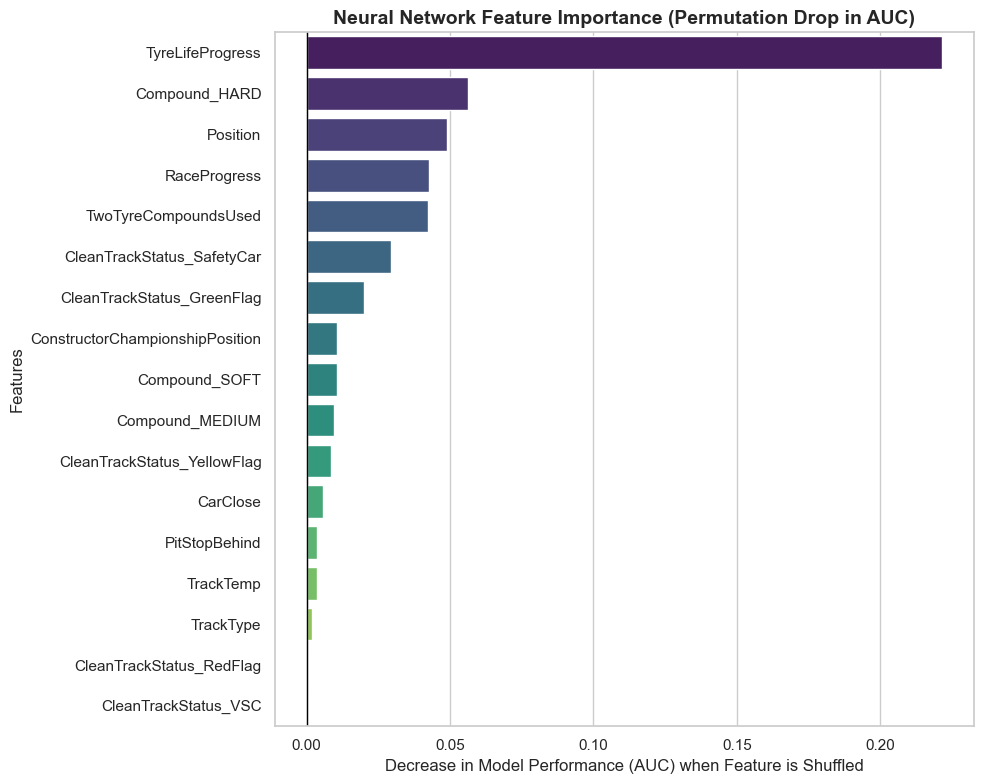


Top 5 Most Important Features:


,Feature,Importance_Score
0,TyreLifeProgress,0.221617
1,Compound_HARD,0.056121
2,Position,0.048908
3,RaceProgress,0.042542
4,TwoTyreCompoundsUsed,0.042331


In [68]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_auc_score

print("Calculating Feature Importance via Permutation (this might take a minute)...")

# ---------------------------------------------------------
# CALCULATE BASELINE PERFORMANCE
# ---------------------------------------------------------
# We use AUC as our metric because it handles imbalanced data (97% vs 3%) very well
baseline_predictions = model.predict(X_test_nn, verbose=0)
baseline_auc = roc_auc_score(y_test_nn, baseline_predictions)
print(f"Baseline Test AUC: {baseline_auc:.4f}")

# ---------------------------------------------------------
# CALCULATE PERMUTATION IMPORTANCE
# ---------------------------------------------------------
importances = {}

# Loop through every single feature in our test set
for column in X_test_nn.columns:
    # Create a fresh copy of the test set
    X_test_shuffled = X_test_nn.copy()
    
    # Shuffle the rows of THIS specific column randomly to destroy its relationship with the target
    X_test_shuffled[column] = np.random.permutation(X_test_shuffled[column].values)
    
    # Predict again with the corrupted data
    shuffled_predictions = model.predict(X_test_shuffled, verbose=0)
    shuffled_auc = roc_auc_score(y_test_nn, shuffled_predictions)
    
    # The drop in performance is the "Importance" of the feature
    # If the drop is large, the feature was very important!
    drop_in_performance = baseline_auc - shuffled_auc
    importances[column] = drop_in_performance

# ---------------------------------------------------------
# FORMAT THE RESULTS
# ---------------------------------------------------------
# Convert the dictionary into a Pandas DataFrame for easy sorting and plotting
df_importance = pd.DataFrame.from_dict(importances, orient='index', columns=['Importance_Score'])
df_importance = df_importance.sort_values(by='Importance_Score', ascending=False).reset_index()
df_importance.rename(columns={'index': 'Feature'}, inplace=True)

# ---------------------------------------------------------
# VISUALIZE THE FEATURE IMPORTANCE
# ---------------------------------------------------------
plt.figure(figsize=(10, 8))
sns.set_theme(style="whitegrid")

# Create a horizontal barplot
sns.barplot(
    data=df_importance, 
    x='Importance_Score', 
    y='Feature', 
    palette='viridis'
)

plt.title("Neural Network Feature Importance (Permutation Drop in AUC)", fontsize=14, fontweight='bold')
plt.xlabel("Decrease in Model Performance (AUC) when Feature is Shuffled", fontsize=12)
plt.ylabel("Features", fontsize=12)
plt.axvline(x=0, color='black', linewidth=1) # Baseline zero

plt.tight_layout()
plt.show()

# Display the top 5 most important features as text
print("\nTop 5 Most Important Features:")
display(df_importance.head(5))

588/588 ━━━━━━━━━━━━━━━━━━━━ 0s 459us/step


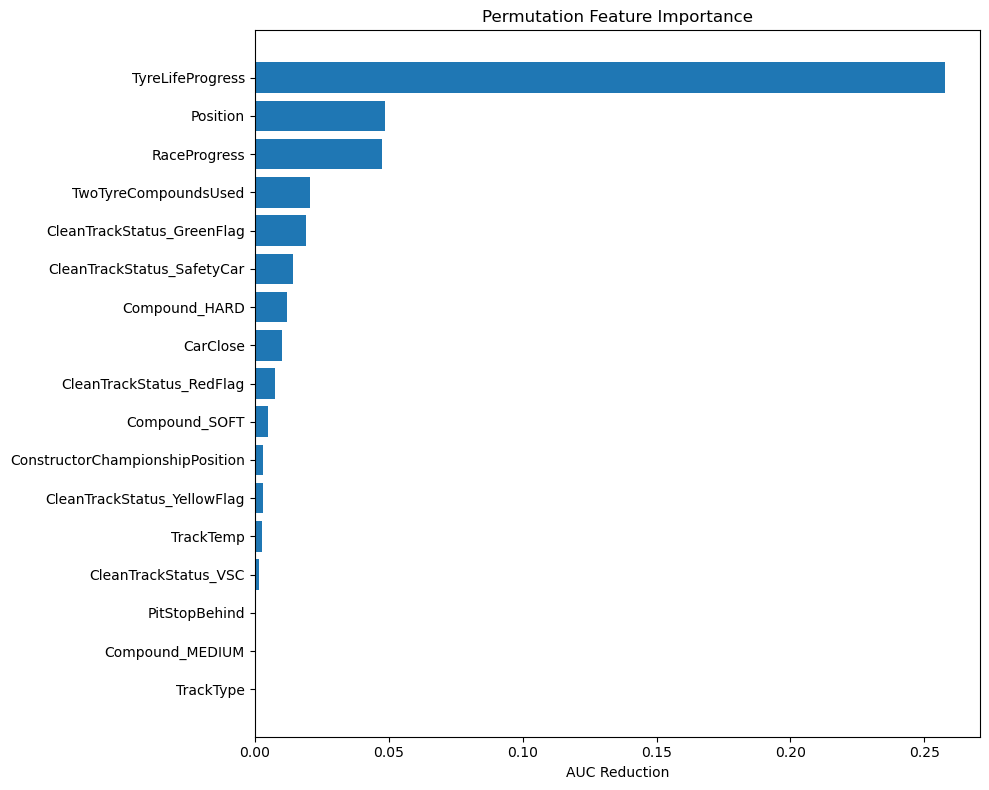

In [19]:
from sklearn.inspection import permutation_importance
from sklearn.base import BaseEstimator, ClassifierMixin
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score


# Permutation Importance con wrapper manuale
import numpy as np
baseline_auc = roc_auc_score(y_valid_nn, nn_model.predict(X_valid_nn))

importances = []
for col in range(X_valid_nn.shape[1]):
    X_permuted = X_valid_nn.copy()
    X_permuted.iloc[:, col] = np.random.permutation(X_permuted.iloc[:, col])
    permuted_auc = roc_auc_score(y_valid_nn, nn_model.predict(X_permuted, verbose=0))
    importances.append(baseline_auc - permuted_auc)

perm_df = pd.DataFrame({
    'Feature': nn_cols_to_keep,
    'Importance': importances
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(10, 8))
plt.barh(perm_df['Feature'], perm_df['Importance'])
plt.xlabel('AUC Reduction')
plt.title('Permutation Feature Importance')
plt.tight_layout()
plt.show()

588/588 ━━━━━━━━━━━━━━━━━━━━ 0s 456us/step


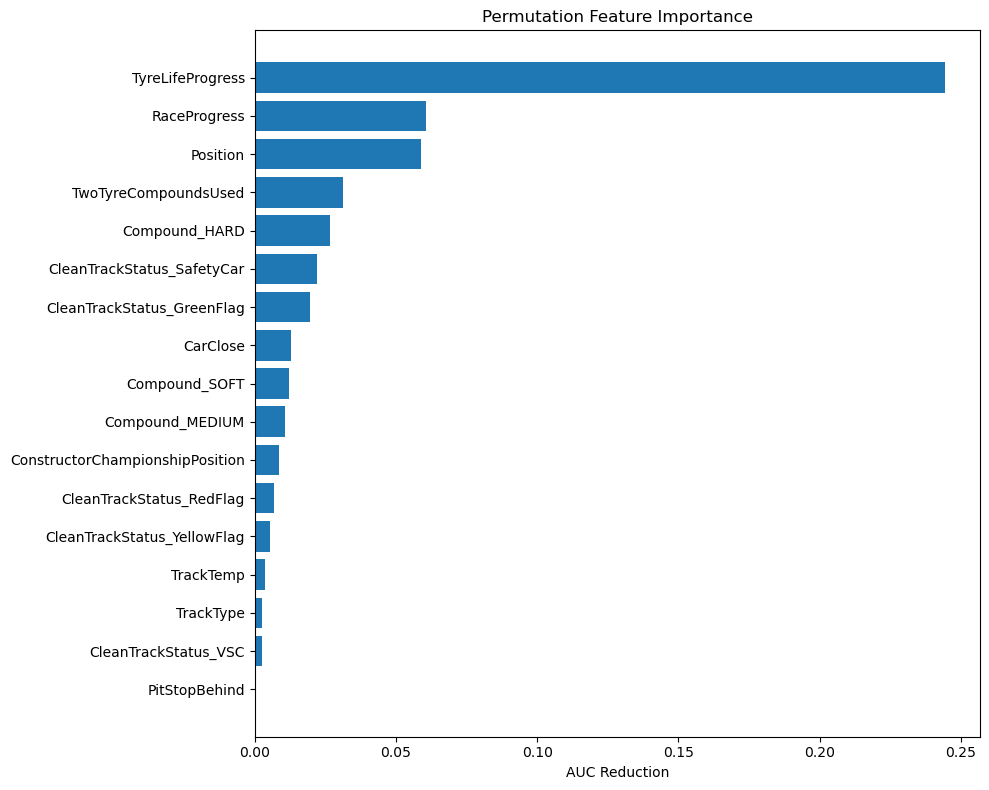

In [44]:
from sklearn.inspection import permutation_importance
from sklearn.base import BaseEstimator, ClassifierMixin
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score


# Permutation Importance con wrapper manuale
import numpy as np
baseline_auc = roc_auc_score(y_valid_nn, model.predict(X_valid_nn))

importances = []
for col in range(X_valid_nn.shape[1]):
    col_importances = []
    for _ in range(30):  # aumenta le ripetizioni
        X_permuted = X_valid_nn.copy()
        X_permuted.iloc[:, col] = np.random.permutation(X_permuted.iloc[:, col])
        permuted_auc = roc_auc_score(y_valid_nn, model.predict(X_permuted, verbose=0))
        col_importances.append(baseline_auc - permuted_auc)
    importances.append(np.mean(col_importances))


perm_df = pd.DataFrame({
    'Feature': nn_cols_to_keep,
    'Importance': importances
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(10, 8))
plt.barh(perm_df['Feature'], perm_df['Importance'])
plt.xlabel('AUC Reduction')
plt.title('Permutation Feature Importance')
plt.tight_layout()
plt.show()

588/588 ━━━━━━━━━━━━━━━━━━━━ 0s 463us/step


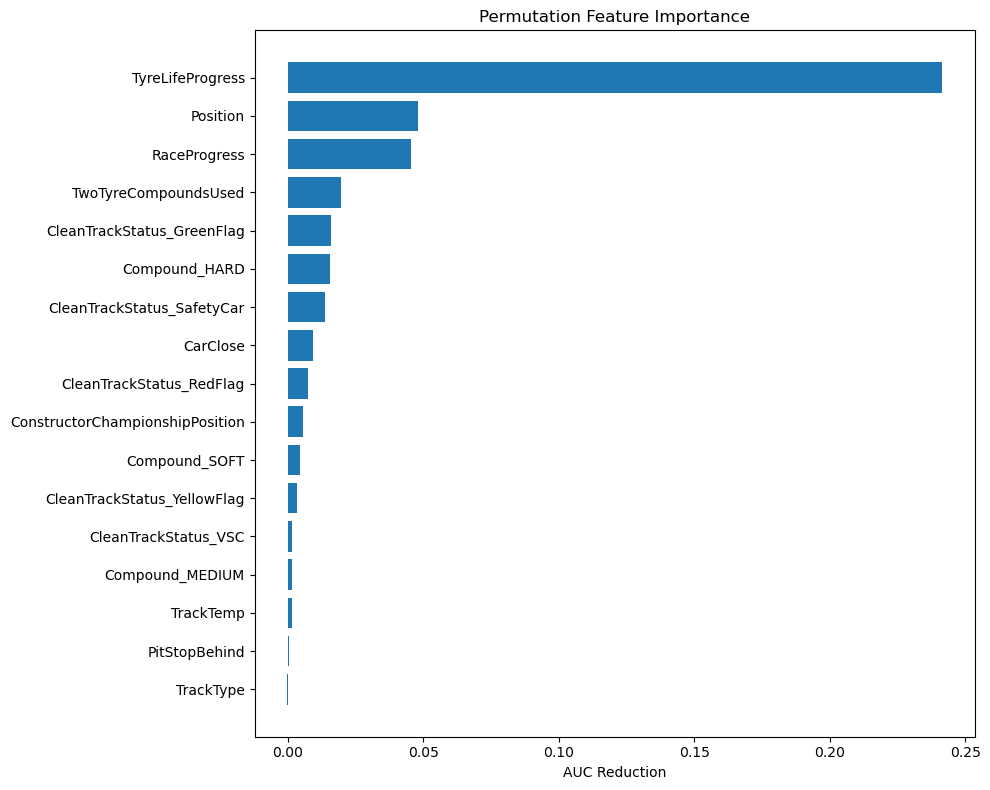

In [21]:
from sklearn.inspection import permutation_importance
from sklearn.base import BaseEstimator, ClassifierMixin
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score


# Permutation Importance con wrapper manuale
import numpy as np
baseline_auc = roc_auc_score(y_valid_nn, nn_model.predict(X_valid_nn))

importances = []
for col in range(X_valid_nn.shape[1]):
    col_importances = []
    for _ in range(30):  # aumenta le ripetizioni
        X_permuted = X_valid_nn.copy()
        X_permuted.iloc[:, col] = np.random.permutation(X_permuted.iloc[:, col])
        permuted_auc = roc_auc_score(y_valid_nn, nn_model.predict(X_permuted, verbose=0))
        col_importances.append(baseline_auc - permuted_auc)
    importances.append(np.mean(col_importances))


perm_df = pd.DataFrame({
    'Feature': nn_cols_to_keep,
    'Importance': importances
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(10, 8))
plt.barh(perm_df['Feature'], perm_df['Importance'])
plt.xlabel('AUC Reduction')
plt.title('Permutation Feature Importance')
plt.tight_layout()
plt.show()

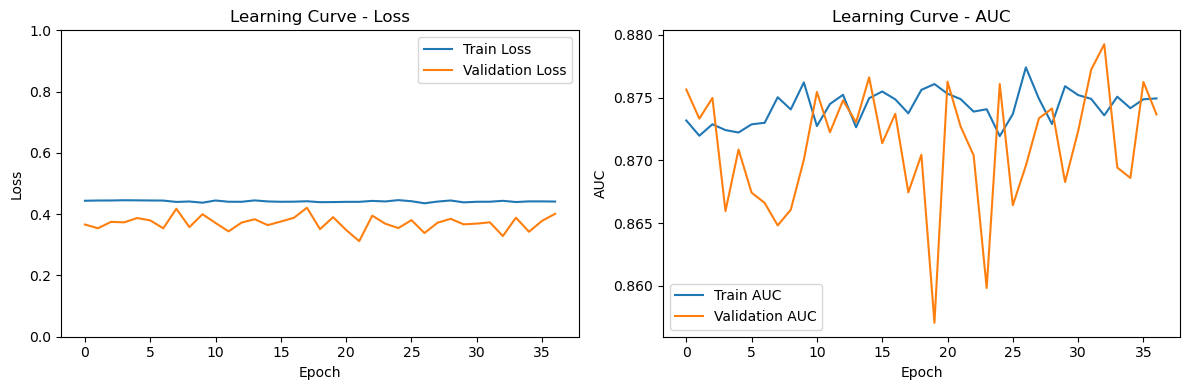

In [50]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Learning Curve - Loss')
plt.ylim(0,1)
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['auc'], label='Train AUC')
plt.plot(history.history['val_auc'], label='Validation AUC')
plt.xlabel('Epoch')
plt.ylabel('AUC')
plt.title('Learning Curve - AUC')
plt.legend()

plt.tight_layout()
plt.show()

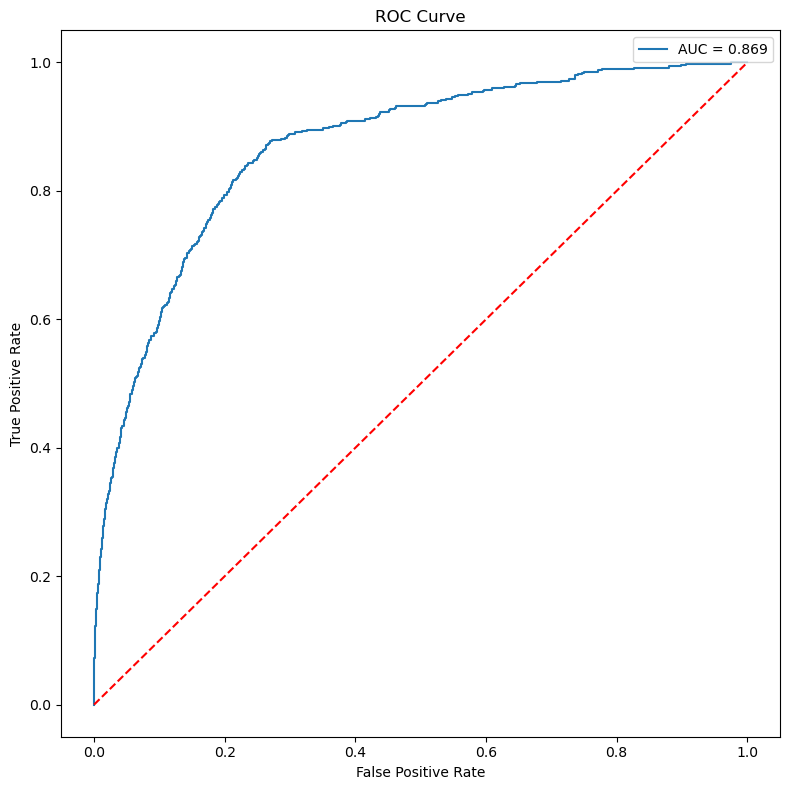

In [34]:
# Curva ROC
from sklearn.metrics import roc_curve, roc_auc_score
y_pred_prob = nn_model.predict(X_test_nn, verbose=0)
fpr, tpr, _ = roc_curve(y_test_nn, y_pred_prob)
roc_auc = roc_auc_score(y_test_nn, y_pred_prob)

plt.figure(figsize=(8,8))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
plt.plot([0,1],[0,1],'r--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.tight_layout()
plt.show()

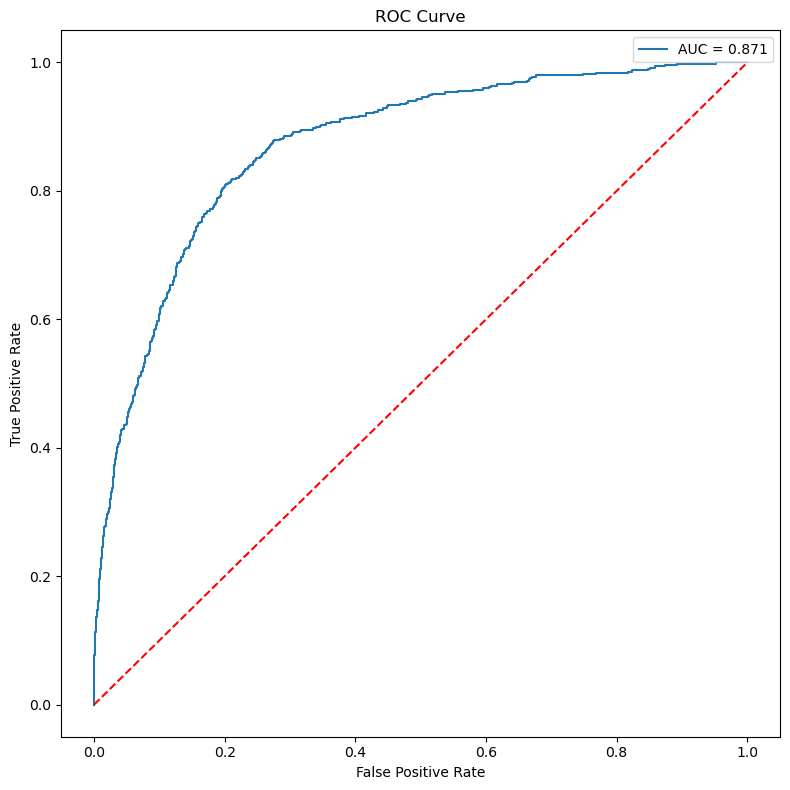

In [51]:
# Curva ROC
from sklearn.metrics import roc_curve, roc_auc_score
y_pred_prob = model.predict(X_test_nn, verbose=0)
fpr, tpr, _ = roc_curve(y_test_nn, y_pred_prob)
roc_auc = roc_auc_score(y_test_nn, y_pred_prob)

plt.figure(figsize=(8,8))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
plt.plot([0,1],[0,1],'r--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.tight_layout()
plt.show()

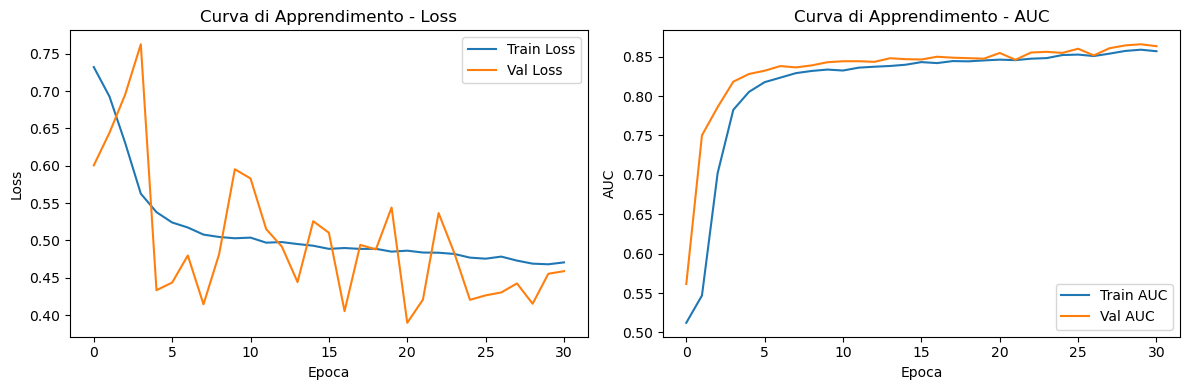

In [ ]:
# Curva di apprendimento (Training History) 64,32,32
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epoca')
plt.ylabel('Loss')
plt.title('Curva di Apprendimento - Loss')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['auc'], label='Train AUC')
plt.plot(history.history['val_auc'], label='Val AUC')
plt.xlabel('Epoca')
plt.ylabel('AUC')
plt.title('Curva di Apprendimento - AUC')
plt.legend()
plt.tight_layout()
plt.show()

### test set

In [52]:
from sklearn.metrics import f1_score, classification_report

y_pred_prob = model.predict(X_test_nn, verbose=0)
y_pred_class = (y_pred_prob >= 0.45).astype(int)  # usa la tua soglia 0.45

print(classification_report(y_test_nn, y_pred_class, 
      target_names=['No Pit Stop', 'Pit Stop']))

              precision    recall  f1-score   support

 No Pit Stop       0.99      0.82      0.90     17328
    Pit Stop       0.11      0.78      0.19       496

    accuracy                           0.81     17824
   macro avg       0.55      0.80      0.54     17824
weighted avg       0.97      0.81      0.88     17824



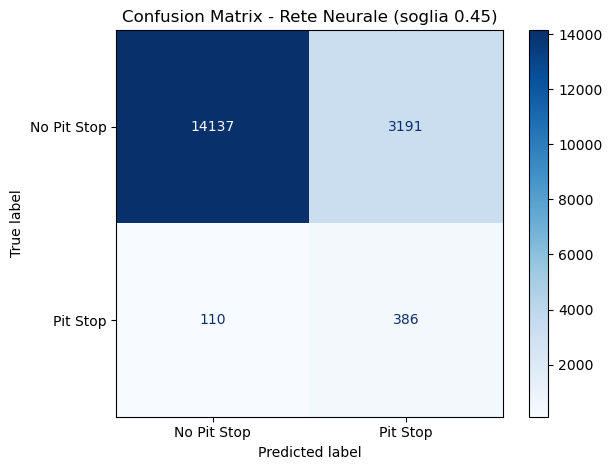

In [53]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test_nn, y_pred_class)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, 
       display_labels=['No Pit Stop', 'Pit Stop'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix - Rete Neurale (soglia 0.45)')
plt.tight_layout()
plt.show()

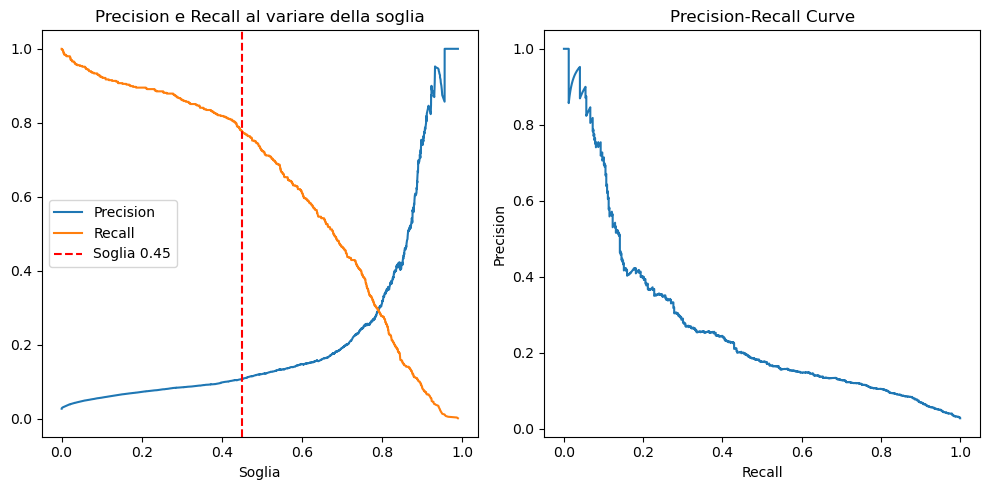

In [54]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_test_nn, y_pred_prob)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(thresholds, precision[:-1], label='Precision')
plt.plot(thresholds, recall[:-1], label='Recall')
plt.axvline(x=0.45, color='red', linestyle='--', label='Soglia 0.45')
plt.xlabel('Soglia')
plt.title('Precision e Recall al variare della soglia')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(recall, precision)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.tight_layout()
plt.show()

              precision    recall  f1-score   support

 No Pit Stop       0.99      0.83      0.90     17328
    Pit Stop       0.11      0.74      0.19       496

    accuracy                           0.83     17824
   macro avg       0.55      0.79      0.55     17824
weighted avg       0.97      0.83      0.88     17824



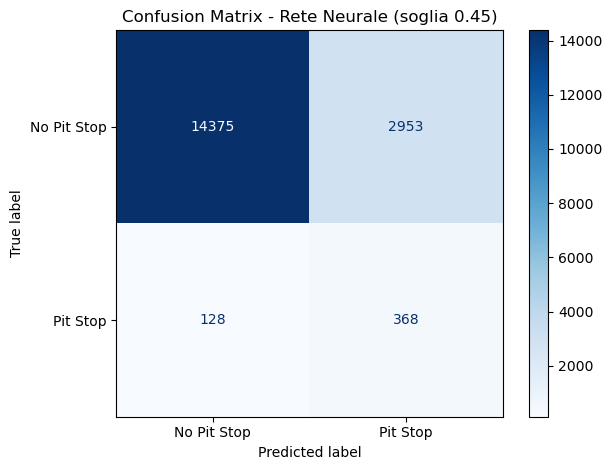

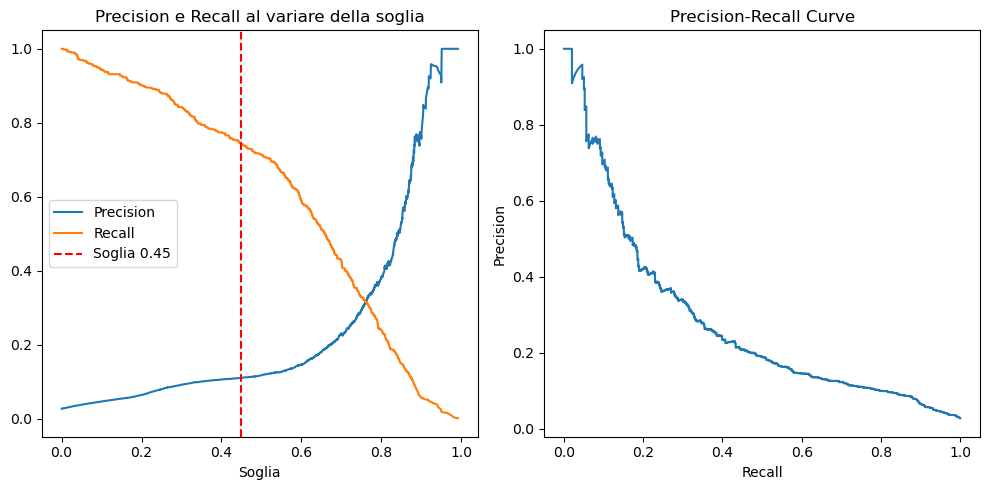

In [42]:
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import f1_score, classification_report

y_pred_prob = nn_model.predict(X_test_nn, verbose=0)
y_pred_class = (y_pred_prob >= 0.45).astype(int)  # usa la tua soglia 0.45

print(classification_report(y_test_nn, y_pred_class, 
      target_names=['No Pit Stop', 'Pit Stop']))


cm = confusion_matrix(y_test_nn, y_pred_class)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, 
       display_labels=['No Pit Stop', 'Pit Stop'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix - Rete Neurale (soglia 0.45)')
plt.tight_layout()
plt.show()



precision, recall, thresholds = precision_recall_curve(y_test_nn, y_pred_prob)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(thresholds, precision[:-1], label='Precision')
plt.plot(thresholds, recall[:-1], label='Recall')
plt.axvline(x=0.45, color='red', linestyle='--', label='Soglia 0.45')
plt.xlabel('Soglia')
plt.title('Precision e Recall al variare della soglia')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(recall, precision)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.tight_layout()
plt.show()